<a href="https://colab.research.google.com/github/Lauranayala/TFM/blob/main/Colab_TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CARGA DE LOS DATOS


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

RUTA = '/content/drive/MyDrive/VIU_Máster_en_Data_Analytics/TFM /Telco-Customer-Churn.csv'
df = pd.read_csv(RUTA)
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Mounted at /content/drive
✅ Dataset cargado: 7,043 filas × 21 columnas


In [ ]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset utilizado es el **Telco Customer Churn**, disponible públicamente en Kaggle (IBM Sample Data). Contiene información sobre **7.043 clientes** de una empresa de telecomunicaciones ficticia con **21 variables**, incluyendo características del cliente, servicios contratados, tipo de contrato, facturación y si el cliente abandonó la compañía (churn).

Cada fila representa un cliente único identificado por `customerID`. La variable objetivo es `Churn`, que indica si el cliente canceló el servicio (`Yes`) o no (`No`).

**2.2 Identificación de Variables**

Las 21 variables del dataset se clasifican en las siguientes categorías:

**Variables de identificación:**
- `customerID`: Identificador único del cliente (no aporta valor predictivo).

**Variables demográficas:**
- `gender`: Género del cliente (Male / Female).
- `SeniorCitizen`: Si el cliente es mayor de 65 años (0 = No, 1 = Sí).
- `Partner`: Si el cliente tiene pareja (Yes / No).
- `Dependents`: Si el cliente tiene dependientes a cargo (Yes / No).

**Variables de relación con la empresa (tenencia):**
- `tenure`: Número de meses que el cliente lleva con la compañía.

**Variables de servicios contratados:**
- `PhoneService`: Si tiene servicio de telefonía (Yes / No).
- `MultipleLines`: Si tiene múltiples líneas telefónicas.
- `InternetService`: Tipo de servicio de internet (DSL, Fiber optic, No).
- `OnlineSecurity`: Si tiene seguridad online contratada.
- `OnlineBackup`: Si tiene backup online contratado.
- `DeviceProtection`: Si tiene protección de dispositivo.
- `TechSupport`: Si tiene soporte técnico.
- `StreamingTV`: Si tiene streaming de TV.
- `StreamingMovies`: Si tiene streaming de películas.

**Variables de contrato y facturación:**
- `Contract`: Tipo de contrato (Month-to-month, One year, Two year).
- `PaperlessBilling`: Si usa facturación sin papel (Yes / No).
- `PaymentMethod`: Método de pago (Electronic check, Mailed check, Bank transfer, Credit card).
- `MonthlyCharges`: Cargo mensual en dólares (numérica continua).
- `TotalCharges`: Cargo total acumulado en dólares (numérica continua).

**Variable objetivo:**
- `Churn`: Si el cliente abandonó la compañía (Yes / No).

**Análisis calidad de datos**

Se realiza una inspección inicial del dataset para identificar posibles problemas de calidad: valores nulos, tipos de datos incorrectos, duplicados y distribución de la variable objetivo.

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Valores nulos
print("\n🔍 Valores nulos por variable:")
nulos = df.isnull().sum()
print(nulos[nulos >= 0].to_string())


🔍 Valores nulos por variable:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0


In [ ]:
df.duplicated().sum()

np.int64(0)

Durante el análisis inicial se comprobó que el dataset no presenta valores nulos ni registros duplicados con los comandos isnull().sum(), duplicated().sum(), lo que facilita el proceso de preprocesamiento y garantiza una mayor consistencia de la información disponible.

Sin embargo en la variable TotalCharges se ve que aparece como tipo de dato object, por lo que en el procesamiento se tratara esta variable.



**Limpieza**

Se descarta la columna de identificación (`customerID`) por no aportar valor predictivo, y se corrige el tipo de dato de `TotalCharges`.

Codificación de variables categóricas.
Escalado si procede.
Tratamiento de desbalance y revisión de sesgos potenciales.


In [ ]:
# Copia de trabajo para no modificar el dataset original
df_clean = df.copy()

# Eliminamos customerID (no aporta valor predictivo)
df_clean.drop(columns=['customerID'], inplace=True)

# Corregimos el tipo de dato de TotalCharges (viene como texto/object)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Revisamos cuántos valores nulos genera la conversión
print('Nulos en TotalCharges tras conversión:', df_clean['TotalCharges'].isnull().sum())
df_clean[df_clean['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Nulos en TotalCharges tras conversión: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [ ]:
# Imputamos con 0, ya que corresponden a clientes con tenure = 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

Durante la fase de limpieza se identificó que la variable TotalCharges, pese a representar un importe monetario, estaba codificada como tipo objeto (texto), por lo que fue necesario convertirla a formato numérico. Este proceso de conversión reveló la existencia de 11 registros con valores no interpretables numéricamente, equivalentes a un 0,15% del total de observaciones, los cuales quedaron marcados como valores nulos. Un análisis más detallado permitió comprobar que la totalidad de estos casos correspondía a clientes con una antigüedad (tenure) igual a cero, es decir, clientes de reciente incorporación que aún no habían completado su primer ciclo de facturación. Dado que TotalCharges representa el importe acumulado facturado desde el inicio de la relación contractual, se determinó que el valor ausente no constituía un error de captura, sino que se correspondía con la ausencia real de facturación acumulada en ese momento. En consecuencia, se optó por imputar estos valores con 0, en lugar de eliminarlos, dado que dicha imputación resulta coherente con la lógica de negocio subyacente y permite conservar información relevante sobre un segmento de clientes de particular interés para el análisis de abandono, como son los clientes recién adquiridos.


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
# Codificación de la variable objetivo
# Codificamos Churn: Yes -> 1, No -> 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Comprobamos la distribución de clases
print(df_clean['Churn'].value_counts())
print(df_clean['Churn'].value_counts(normalize=True) * 100)

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


La variable objetivo Churn se presenta originalmente en formato de texto, con las categorías "Yes" y "No", por lo que fue necesario codificarla numéricamente como 1 y 0, respectivamente, para poder utilizarla en el análisis y en el posterior modelado. Esta transformación se realizó durante la fase de limpieza y calidad de datos, y no en la etapa de preprocesamiento, debido a que se trata de una corrección de formato básica sobre la variable, independiente de las decisiones posteriores de modelado. A diferencia de otras transformaciones como la codificación de variables predictoras o el escalado, que dependen de la división entre conjuntos de entrenamiento y prueba y del algoritmo utilizado, la codificación de la variable objetivo no está condicionada por ninguna de estas decisiones, por lo que resultó más coherente realizarla en la fase inicial, permitiendo además su uso directo durante el análisis exploratorio de datos.

In [ ]:
df_clean.to_csv('/content/drive/MyDrive/VIU_Máster_en_Data_Analytics/TFM /df_clean.csv', index=False)
print('df_clean guardado correctamente en Drive.')

df_clean guardado correctamente en Drive.


In [ ]:
df_clean = pd.read_csv('/content/drive/MyDrive/VIU_Máster_en_Data_Analytics/TFM /df_clean.csv')
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**2. EDA - ANALISIS EXPLORATORIO**

In [ ]:
import os

# Ruta donde se guardarán todas las imágenes del EDA para la memoria
ruta_imagenes = '/content/drive/MyDrive/VIU_Máster_en_Data_Analytics/TFM /Imagenes/'
os.makedirs(ruta_imagenes, exist_ok=True)

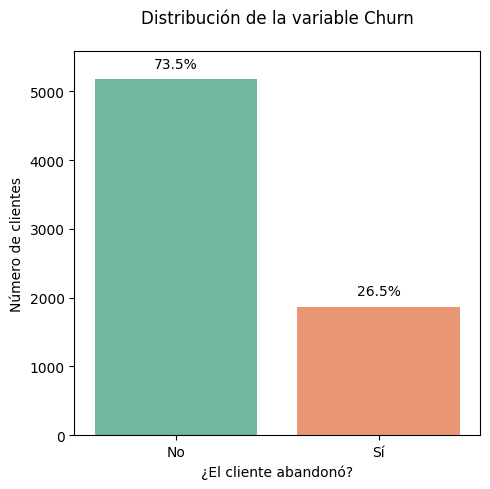

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Versión legible de Churn solo para el gráfico
churn_legible = df_clean['Churn'].map({0: 'No', 1: 'Sí'})
total = len(df_clean)
max_conteo = churn_legible.value_counts().max()

plt.figure(figsize=(5,5))
ax = sns.countplot(x=churn_legible, hue=churn_legible, palette='Set2',
                    order=['No', 'Sí'], legend=False)

plt.title('Distribución de la variable Churn', pad=20)
plt.xlabel('¿El cliente abandonó?')
plt.ylabel('Número de clientes')
plt.ylim(0, max_conteo * 1.08)  # damos espacio extra arriba para las etiquetas

# Porcentaje encima de cada barra, con un pequeño desplazamiento hacia arriba
for barra in ax.patches:
    altura = barra.get_height()
    porcentaje = f'{100 * altura / total:.1f}%'
    ax.annotate(porcentaje,
                (barra.get_x() + barra.get_width() / 2, altura),
                ha='center', va='bottom', fontsize=10,
                xytext=(0, 6), textcoords='offset points')

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_1.png', dpi=300, bbox_inches='tight')
plt.show()

Como primer paso del análisis exploratorio, se examinó la distribución de la variable objetivo, Churn, con el fin de comprobar el nivel de balance entre las dos clases posibles. Los resultados muestran que el 73,5% de los clientes de la muestra permanecen activos en la compañía, mientras que el 26,5% restante ha cancelado el servicio. Esta diferencia indica que el dataset presenta un desbalance moderado entre clases, sin llegar a ser extremo. Este hallazgo resulta relevante de cara al desarrollo del modelo predictivo, ya que un desbalance de esta magnitud puede llevar a que los algoritmos de clasificación tiendan a favorecer la predicción de la clase mayoritaria (clientes que no abandonan), en detrimento de la correcta identificación de los clientes que sí lo hacen, que son precisamente los de mayor interés para el negocio. Por este motivo, esta observación deberá tenerse en cuenta más adelante, en la fase de preprocesamiento, donde será necesario aplicar alguna estrategia que permita compensar dicho desbalance durante el entrenamiento de los modelos

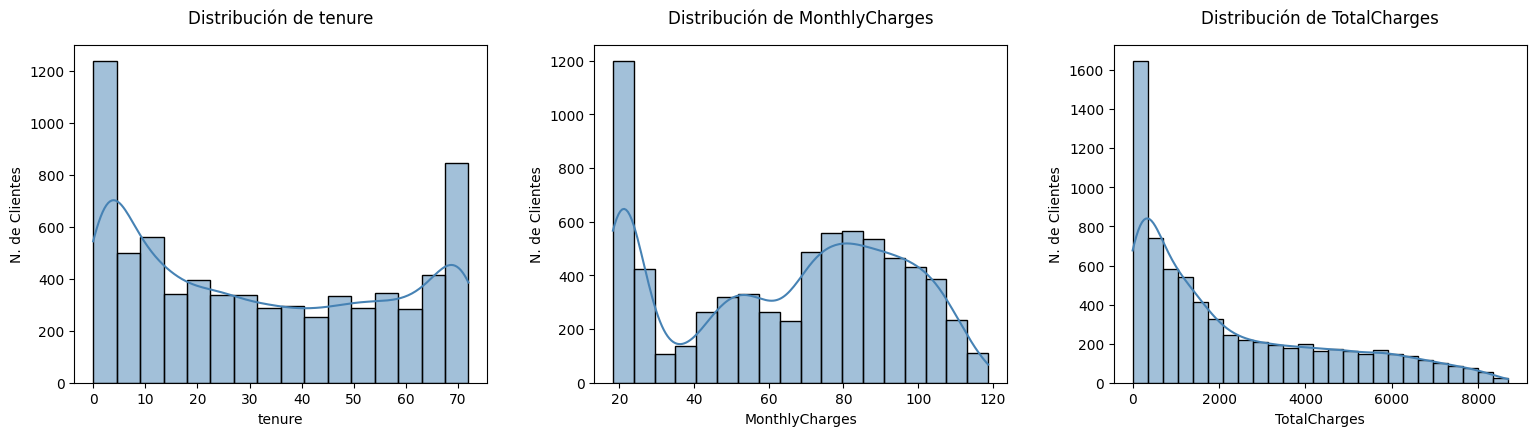

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, var in enumerate(variables_numericas):
    sns.histplot(data=df_clean, x=var, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribución de {var}', fontsize=12, pad=15)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('N. de Clientes', fontsize=10)

plt.tight_layout(pad=3, w_pad=3)
plt.savefig(f'{ruta_imagenes}imagen_2_distribucion_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

En tenure (antigüedad en meses) se observa una distribución con dos picos claros: uno muy alto al principio (clientes con muy poca antigüedad, entre 0 y 10 meses) y otro pico notable al final (clientes con unos 70-72 meses, es decir, muy fieles). En medio hay menos clientes. Esto sugiere que la base de clientes está compuesta por dos grupos bastante distintos: gente que acaba de entrar y gente muy consolidada, con relativamente menos clientes "a medio camino". Esto es relevante para el churn, porque intuitivamente los clientes nuevos suelen ser los que tienen más riesgo de abandonar pronto.
En MonthlyCharges (cargo mensual) también se ve una forma con varios grupos: un pico bajo, alrededor de 20 dólares (probablemente clientes con servicios básicos, como solo teléfono, sin internet), y luego una concentración más amplia entre 70 y 100 dólares (clientes con paquetes más completos, como fibra óptica y servicios adicionales). Esto indica que no hay un cliente "típico", sino distintos perfiles de consumo.
En TotalCharges (cargo total acumulado) se observa una distribución claramente asimétrica hacia la derecha (sesgo positivo): la mayoría de los clientes acumula montos bajos, y muy pocos alcanzan varios miles de dólares. Esto es coherente con lo visto en tenure, ya que muchos clientes llevan poco tiempo en la empresa y por tanto no han acumulado grandes cargos todavía.

**PARRAFO MEMORIA**

El análisis de las variables numéricas continuas reveló patrones relevantes en el comportamiento de los clientes. La variable tenure presenta una distribución bimodal, con una elevada concentración de clientes de muy poca antigüedad (entre 0 y 10 meses) y otra concentración importante de clientes con una permanencia cercana a los 72 meses, lo que sugiere la coexistencia de dos perfiles diferenciados: clientes recién incorporados y clientes de larga fidelidad, con una proporción menor de casos intermedios. Por su parte, la variable MonthlyCharges también muestra varios grupos de concentración, uno en torno a los 20 dólares, asociado probablemente a clientes con servicios básicos, y otro más amplio entre 70 y 100 dólares, vinculado a clientes con paquetes de servicios más completos. Finalmente, la variable TotalCharges presenta una distribución con marcada asimetría positiva, donde la mayoría de los clientes acumula importes reducidos y solo una minoría alcanza valores elevados, resultado coherente con la elevada proporción de clientes de escasa antigüedad observada anteriormente.

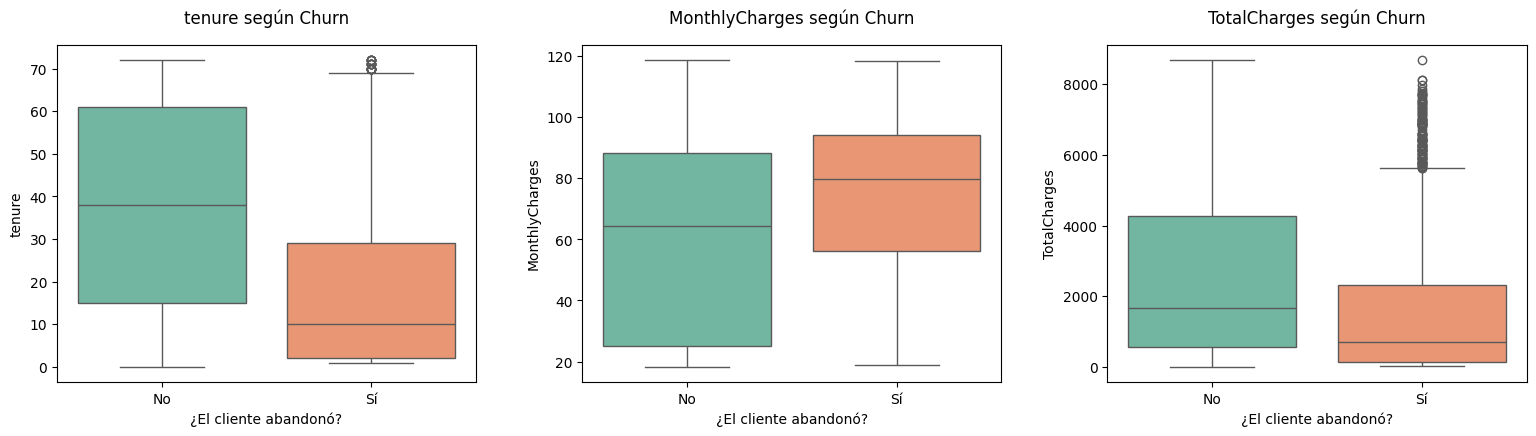

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
churn_legible = df_clean['Churn'].map({0: 'No', 1: 'Sí'})

for i, var in enumerate(variables_numericas):
    sns.boxplot(x=churn_legible, y=df_clean[var], hue=churn_legible,
                palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'{var} según Churn', fontsize=12, pad=15)
    axes[i].set_xlabel('¿El cliente abandonó?', fontsize=10)
    axes[i].set_ylabel(var, fontsize=10)

plt.tight_layout(pad=3, w_pad=3)
plt.savefig(f'{ruta_imagenes}imagen_3_numericas_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

Tenure según Churn: se ve una diferencia bastante clara. Los clientes que no abandonan (No) tienen una mediana de antigüedad bastante más alta, alrededor de 35-40 meses, con una caja que llega hasta cerca de 60. En cambio, los clientes que sí abandonan (Sí) tienen una mediana mucho más baja, en torno a 12-15 meses. Esto confirma numéricamente algo que ya intuíamos en el gráfico anterior: los clientes con poca antigüedad son los que más probabilidad tienen de irse.

MonthlyCharges según Churn: aquí el patrón es el contrario de lo que uno esperaría a primera vista. Los clientes que abandonan tienden a tener cargos mensuales más altos (mediana cercana a 80 dólares) que los que se quedan (mediana cercana a 60-65 dólares). Esto sugiere que pagar más al mes podría estar relacionado con mayor insatisfacción o con sentir que no se obtiene suficiente valor por el precio, lo cual es un hallazgo interesante para las estrategias de fidelización.

TotalCharges según Churn: los clientes que no abandonan acumulan montos totales mucho más altos (mediana de casi 2.000 dólares, con clientes que llegan a superar los 8.000), mientras que los que abandonan tienen una mediana baja, de unos 700-800 dólares. Esto no es contradictorio con el punto anterior, simplemente refleja que, aunque pagan más al mes, los clientes que se van llevan tan poco tiempo en la empresa que no han tenido tiempo de acumular un total alto.

En conjunto, estos tres gráficos cuentan una historia coherente: el perfil típico de cliente en riesgo de churn es alguien relativamente nuevo, que paga una cuota mensual alta, y que por lo tanto aún no ha acumulado un gasto total elevado.

**memoria**

Con el fin de explorar la relación entre las variables numéricas y el abandono de clientes, se compararon las distribuciones de tenure, MonthlyCharges y TotalCharges entre los clientes que cancelaron el servicio y los que permanecieron activos. Los resultados muestran que los clientes que abandonan presentan una antigüedad notablemente inferior, con una mediana en torno a los 12-15 meses, frente a los 35-40 meses de mediana observados entre los clientes que continúan en la compañía, lo que refuerza la hipótesis de que los clientes de reciente incorporación constituyen un segmento de mayor riesgo.

Asimismo, se observó que los clientes que abandonan tienden a pagar cargos mensuales más elevados, con una mediana próxima a los 80 dólares frente a los 60-65 dólares del grupo que permanece, lo que podría estar asociado a una menor percepción de valor respecto al precio pagado. En cuanto a TotalCharges, los clientes que abandonan presentan valores acumulados considerablemente más bajos, resultado coherente con su menor antigüedad en la compañía. En conjunto, estos hallazgos sugieren que el perfil de cliente con mayor riesgo de abandono corresponde a clientes relativamente nuevos que asumen cuotas mensuales elevadas.

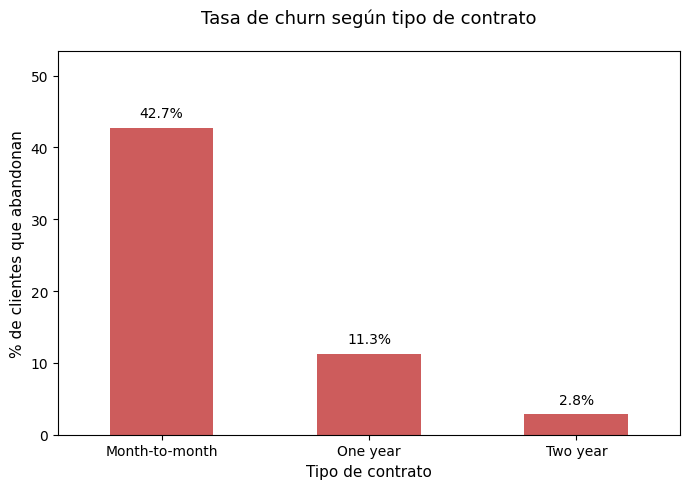

In [ ]:
plt.figure(figsize=(7, 5))

# Calculamos el % de churn dentro de cada tipo de contrato
churn_por_contrato = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
churn_por_contrato.columns = ['No', 'Sí']
tasa_ordenada = churn_por_contrato['Sí'].sort_values(ascending=False)

ax = tasa_ordenada.plot(kind='bar', color='indianred')
plt.title('Tasa de churn según tipo de contrato', fontsize=13, pad=20)
plt.xlabel('Tipo de contrato', fontsize=11)
plt.ylabel('% de clientes que abandonan', fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, tasa_ordenada.max() * 1.25)

for i, valor in enumerate(tasa_ordenada):
    plt.text(i, valor + 1.5, f'{valor:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_4_churn_por_contrato.png', dpi=300, bbox_inches='tight')
plt.show()

Excelente resultado, y muy claro. Los clientes con contrato mensual (Month-to-month) tienen una tasa de churn del 42,7%, es decir, casi la mitad se van. En cambio, los que tienen contrato anual (One year) bajan a 11,3%, y los que tienen contrato de dos años (Two year) caen a solo 2,8%. La diferencia es enorme: un cliente con contrato mensual tiene más de 15 veces más probabilidad de abandonar que uno con contrato de dos años.
Esto tiene bastante sentido de negocio: un contrato mensual no ata al cliente a ningún compromiso, así que cancelar es tan fácil como decidirlo de un mes a otro, mientras que los contratos más largos generan una barrera natural de salida (y probablemente atraen a clientes ya más comprometidos con la compañía desde el principio). Es, con diferencia, una de las variables más predictivas que vas a encontrar en todo el análisis, y probablemente sea clave también en la fase de modelado explicable, ya que factores como este son fáciles de comunicar al área de negocio para diseñar estrategias de fidelización (por ejemplo, incentivar la migración de clientes mensuales hacia contratos más largos).

**MEMORIA**

El análisis de la tasa de churn según el tipo de contrato reveló una de las relaciones más marcadas de todo el estudio. Los clientes con contrato mensual (Month-to-month) presentan una tasa de abandono del 42,7%, muy superior a la observada entre los clientes con contrato anual (11,3%) y, especialmente, a la de los clientes con contrato de dos años (2,8%). Esta diferencia sugiere que la ausencia de un compromiso contractual a largo plazo facilita considerablemente la decisión de cancelar el servicio, mientras que los contratos de mayor duración actúan como una barrera de salida que reduce sustancialmente el riesgo de abandono. Este resultado apunta a Contract como una de las variables con mayor capacidad predictiva del conjunto de datos, así como una palanca relevante de cara al diseño de estrategias de fidelización orientadas a migrar a los clientes hacia modalidades contractuales de mayor duración.

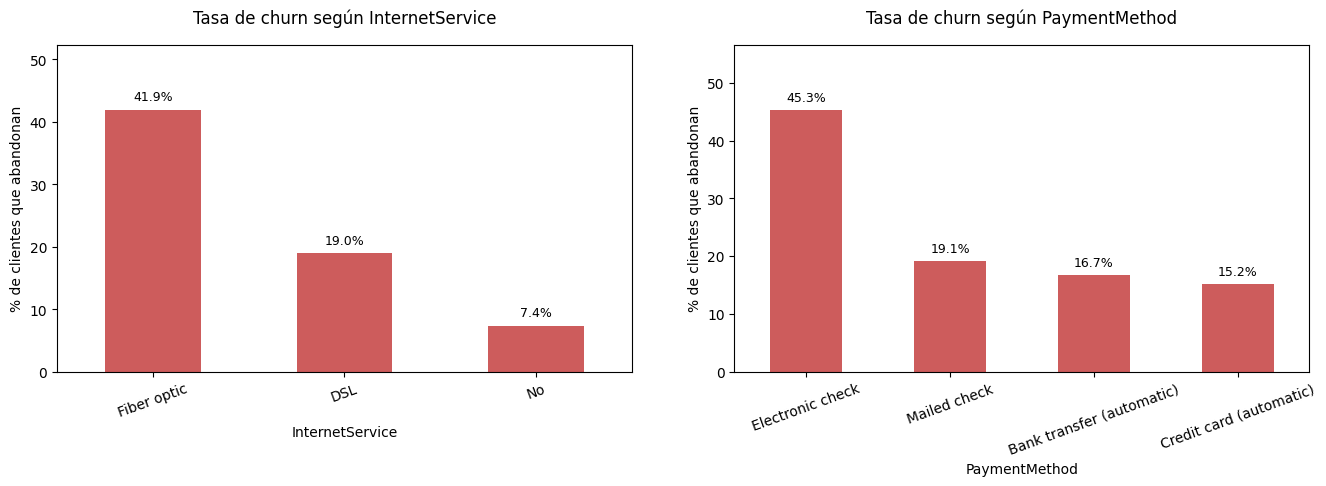

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

variables_categoricas = ['InternetService', 'PaymentMethod']

for i, var in enumerate(variables_categoricas):
    churn_por_categoria = pd.crosstab(df_clean[var], df_clean['Churn'], normalize='index') * 100
    churn_por_categoria.columns = ['No', 'Sí']
    tasa_ordenada = churn_por_categoria['Sí'].sort_values(ascending=False)

    tasa_ordenada.plot(kind='bar', color='indianred', ax=axes[i])
    axes[i].set_title(f'Tasa de churn según {var}', fontsize=12, pad=15)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('% de clientes que abandonan', fontsize=10)
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].set_ylim(0, tasa_ordenada.max() * 1.25)

    for j, valor in enumerate(tasa_ordenada):
        axes[i].text(j, valor + 1.5, f'{valor:.1f}%', ha='center', fontsize=9)

plt.tight_layout(pad=3, w_pad=4)
plt.savefig(f'{ruta_imagenes}imagen_5_internet_pago_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

Otro par de resultados muy informativos. En InternetService, los clientes con fibra óptica (Fiber optic) tienen una tasa de churn del 41,9%, muy superior a la de los clientes con DSL (19,0%) y a la de quienes no tienen internet contratado (7,4%). Esto puede parecer contraintuitivo a primera vista (la fibra suele ser el servicio "premium"), pero probablemente esté relacionado con lo que vimos antes en MonthlyCharges: la fibra óptica es más cara, y ya vimos que los clientes con cuotas más altas abandonan más. También podría reflejar problemas de calidad de servicio o de percepción de precio-valor en ese segmento, algo que podrías mencionar como hipótesis a explorar.
En PaymentMethod, destaca claramente el método "Electronic check", con una tasa de churn del 45,3%, muy por encima de "Mailed check" (19,1%), "Bank transfer automatic" (16,7%) y "Credit card automatic" (15,2%). Aquí el patrón es interesante: los métodos de pago automáticos (transferencia bancaria y tarjeta de crédito) tienen tasas de abandono claramente más bajas que los métodos manuales (cheque electrónico y cheque por correo). Esto tiene sentido, porque un pago automático implica menos fricción y menos "puntos de decisión" en los que el cliente podría plantearse cancelar, mientras que gestionar el pago manualmente cada vez podría estar asociado a clientes menos comprometidos con la relación.

**MEMORIA**

El análisis de la tasa de churn según el tipo de servicio de internet mostró que los clientes con fibra óptica presentan la tasa de abandono más elevada (41,9%), muy por encima de los clientes con DSL (19,0%) y de aquellos sin servicio de internet contratado (7,4%). Este resultado podría estar vinculado al mayor coste asociado a este tipo de servicio, en línea con la relación observada previamente entre cargos mensuales elevados y mayor propensión al abandono. Por otro lado, el análisis según el método de pago reveló que los clientes que utilizan cheque electrónico presentan una tasa de churn considerablemente superior (45,3%) a la del resto de métodos, especialmente frente a los métodos de pago automático como la transferencia bancaria (16,7%) o la tarjeta de crédito (15,2%). Este patrón sugiere que los métodos de pago automatizados podrían estar asociados a una relación más estable y de menor fricción con la compañía, mientras que los métodos de gestión manual podrían reflejar un perfil de cliente con menor grado de compromiso o fidelización.

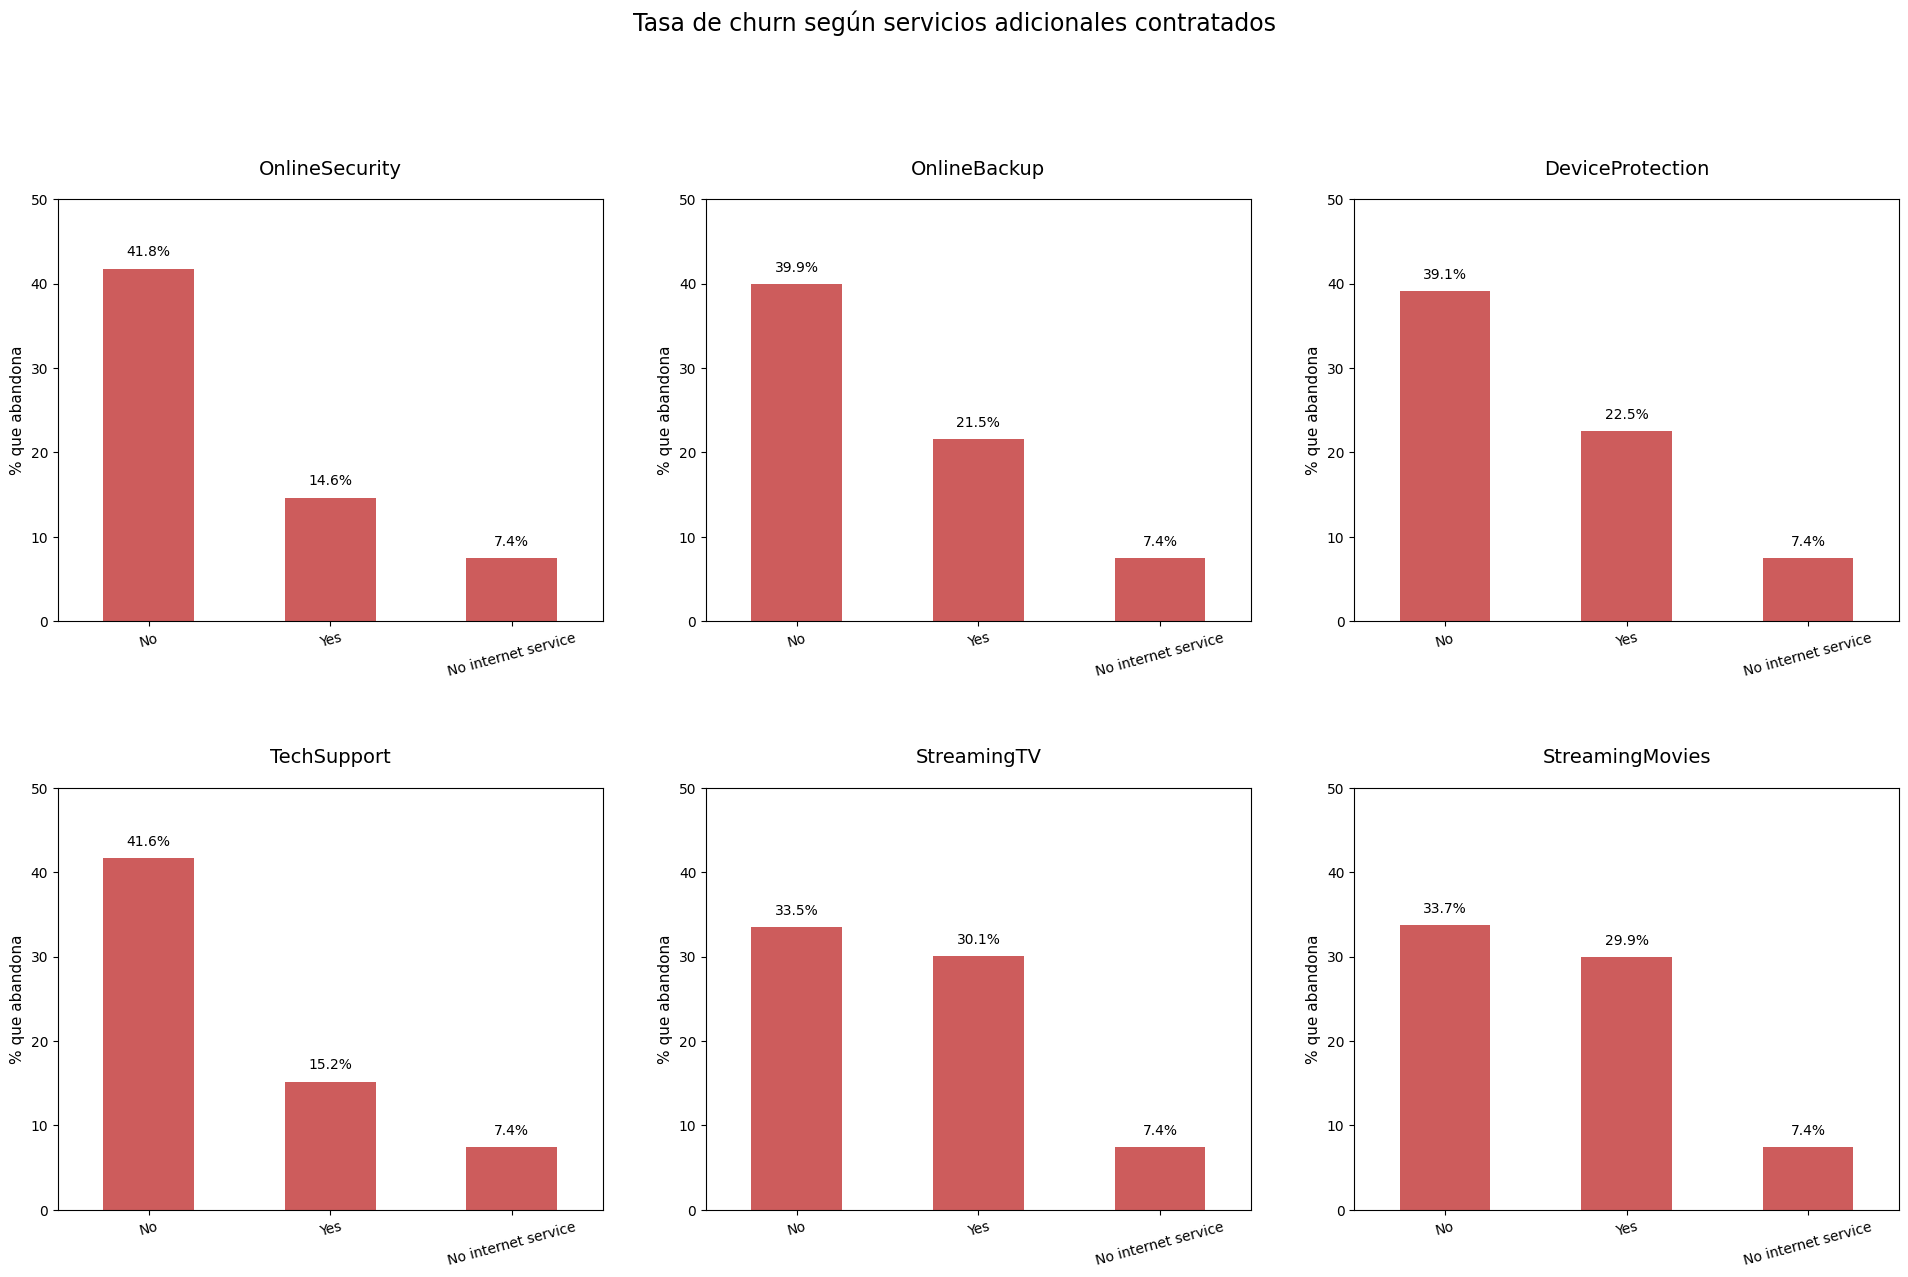

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

variables_servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']

for i, var in enumerate(variables_servicios):
    churn_por_categoria = pd.crosstab(df_clean[var], df_clean['Churn'], normalize='index') * 100
    churn_por_categoria.columns = ['No', 'Sí']
    tasa_ordenada = churn_por_categoria['Sí'].sort_values(ascending=False)

    tasa_ordenada.plot(kind='bar', color='indianred', ax=axes[i])
    axes[i].set_title(f'{var}', fontsize=14, pad=18)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% que abandona', fontsize=11)
    axes[i].tick_params(axis='x', rotation=15, labelsize=10)
    axes[i].set_ylim(0, 50)  # mismo tope fijo para las seis gráficas

    for j, valor in enumerate(tasa_ordenada):
        axes[i].text(j, valor + 1.5, f'{valor:.1f}%', ha='center', fontsize=10)

fig.suptitle('Tasa de churn según servicios adicionales contratados', fontsize=17, y=1.01)
plt.tight_layout(pad=4, w_pad=4, h_pad=5)
plt.savefig(f'{ruta_imagenes}imagen_6_servicios_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

Aquí aparece un patrón muy consistente en cuatro de los seis servicios: OnlineSecurity, OnlineBackup, DeviceProtection y TechSupport. En los cuatro casos, los clientes que NO tienen el servicio contratado presentan una tasa de churn alta, entre el 39% y el 42%, mientras que los que SÍ lo tienen contratado bajan a valores bastante menores, entre el 14,6% y el 22,5%. Es decir, contratar estos servicios adicionales de seguridad/soporte parece asociarse con una permanencia bastante mayor en la compañía. Tiene sentido de negocio: son servicios que aportan valor añadido y "atan" más al cliente, y probablemente también los contratan clientes ya de por sí más comprometidos con la empresa.

En cambio, StreamingTV y StreamingMovies muestran un patrón bastante distinto: la diferencia entre tener el servicio (~30%) y no tenerlo (~33,5%) es mucho más pequeña, de solo 3-4 puntos porcentuales. Esto sugiere que estos dos servicios de streaming tienen mucha menos capacidad predictiva sobre el churn que los otros cuatro; son servicios más "de entretenimiento" y menos ligados a la percepción de seguridad o soporte técnico, así que no funcionan igual como "ancla" del cliente.

Un detalle que vale la pena anotar: en los seis gráficos, la categoría "No internet service" tiene exactamente la misma tasa de churn (7,4%). No es casualidad: es literalmente el mismo grupo de clientes en los seis casos (los que no tienen internet contratado y, por tanto, no pueden tener ninguno de estos servicios adicionales). Es el mismo fenómeno de colinealidad que ya viste en la matriz de correlaciones, así que conviene dejarlo anotado también aquí.

MEMORIA

El análisis de la tasa de churn en función de los servicios adicionales contratados mostró un patrón claramente diferenciado entre dos grupos de variables. Por un lado, OnlineSecurity, OnlineBackup, DeviceProtection y TechSupport presentaron una relación marcada con el abandono: los clientes que no disponían de estos servicios registraron tasas de churn elevadas, entre el 39,1% y el 41,8%, frente a tasas sensiblemente más bajas, entre el 14,6% y el 22,5%, entre quienes sí los tenían contratados. Este resultado sugiere que la contratación de servicios de seguridad, respaldo y soporte técnico se asocia con una mayor fidelización del cliente, posiblemente porque aportan valor percibido adicional y generan una mayor dependencia del servicio contratado.

Por otro lado, las variables StreamingTV y StreamingMovies mostraron diferencias mucho más reducidas entre categorías (33,5% frente a 30,1%, y 33,7% frente a 29,9%, respectivamente), lo que indica una capacidad discriminativa considerablemente menor respecto al abandono en comparación con el resto de servicios adicionales analizados. Este hallazgo resulta coherente con la naturaleza de estos servicios, orientados al entretenimiento, frente a los de seguridad y soporte técnico, más vinculados a la percepción de valor y confianza en el proveedor.

Por último, cabe señalar que la categoría "No internet service" presenta la misma tasa de churn (7,4%) en los seis servicios analizados, dado que corresponde exactamente al mismo subconjunto de clientes sin servicio de internet contratado. Esta circunstancia, ya identificada previamente en el análisis de correlaciones, confirma la existencia de una elevada colinealidad entre las variables asociadas a la ausencia de internet, aspecto que deberá tenerse en cuenta en las fases posteriores de modelado e interpretación.

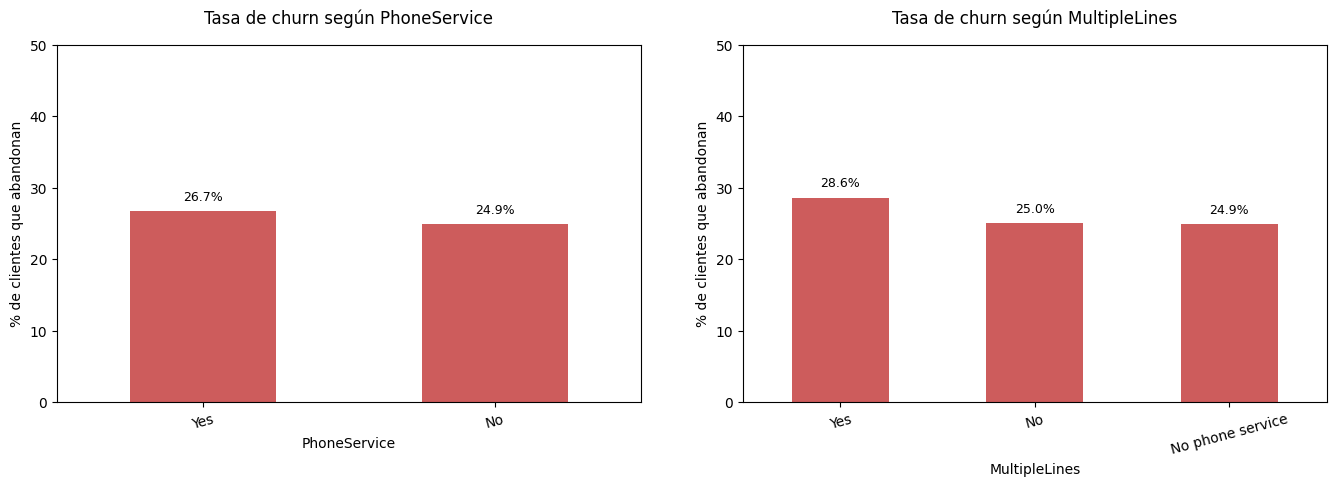

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

variables_telefono = ['PhoneService', 'MultipleLines']

for i, var in enumerate(variables_telefono):
    churn_por_categoria = pd.crosstab(df_clean[var], df_clean['Churn'], normalize='index') * 100
    churn_por_categoria.columns = ['No', 'Sí']
    tasa_ordenada = churn_por_categoria['Sí'].sort_values(ascending=False)

    tasa_ordenada.plot(kind='bar', color='indianred', ax=axes[i])
    axes[i].set_title(f'Tasa de churn según {var}', fontsize=12, pad=15)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('% de clientes que abandonan', fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0,50)

    for j, valor in enumerate(tasa_ordenada):
        axes[i].text(j, valor + 1.5, f'{valor:.1f}%', ha='center', fontsize=9)

plt.tight_layout(pad=3, w_pad=4)
plt.savefig(f'{ruta_imagenes}imagen_7_telefono_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

Aquí el resultado es justo lo contrario de lo que vimos con Contract o PaymentMethod: las diferencias son mínimas. En PhoneService, los clientes que sí tienen el servicio abandonan un 26,7% y los que no lo tienen un 24,9%, apenas 1,8 puntos porcentuales de diferencia. En MultipleLines pasa algo parecido: 28,6% (Yes), 25,0% (No) y 24,9% (No phone service), todos bastante cercanos entre sí y muy próximos también a la tasa general de churn del dataset completo (26,5%).
Esto es un hallazgo tan válido como los anteriores, aunque en sentido contrario: te está diciendo que tener o no servicio telefónico, o tener una o varias líneas, prácticamente no influye en si un cliente abandona o no. Son variables con poca capacidad discriminativa para este problema. Vale la pena mencionarlo en la memoria, porque en un análisis explicable no solo interesa destacar lo que sí influye (como Contract), sino también dejar constancia de lo que no aporta señal relevante, ya que eso también es información útil de cara a la interpretación del modelo final.

**MEMORIA**

A diferencia de los resultados obtenidos con otras variables, el análisis de PhoneService y MultipleLines no reveló diferencias relevantes en la tasa de churn entre sus distintas categorías. Los clientes con servicio telefónico presentan una tasa de abandono del 26,7%, frente al 24,9% de quienes no lo tienen, una diferencia mínima. De forma similar, las distintas categorías de MultipleLines (Yes: 28,6%, No: 25,0%, No phone service: 24,9%) se sitúan todas en valores muy cercanos entre sí y próximos a la tasa media de churn del conjunto de datos (26,5%). Estos resultados sugieren que ambas variables aportan escasa capacidad explicativa respecto al abandono de clientes, a diferencia de variables como el tipo de contrato o el método de pago, que sí mostraron diferencias marcadas entre categorías.

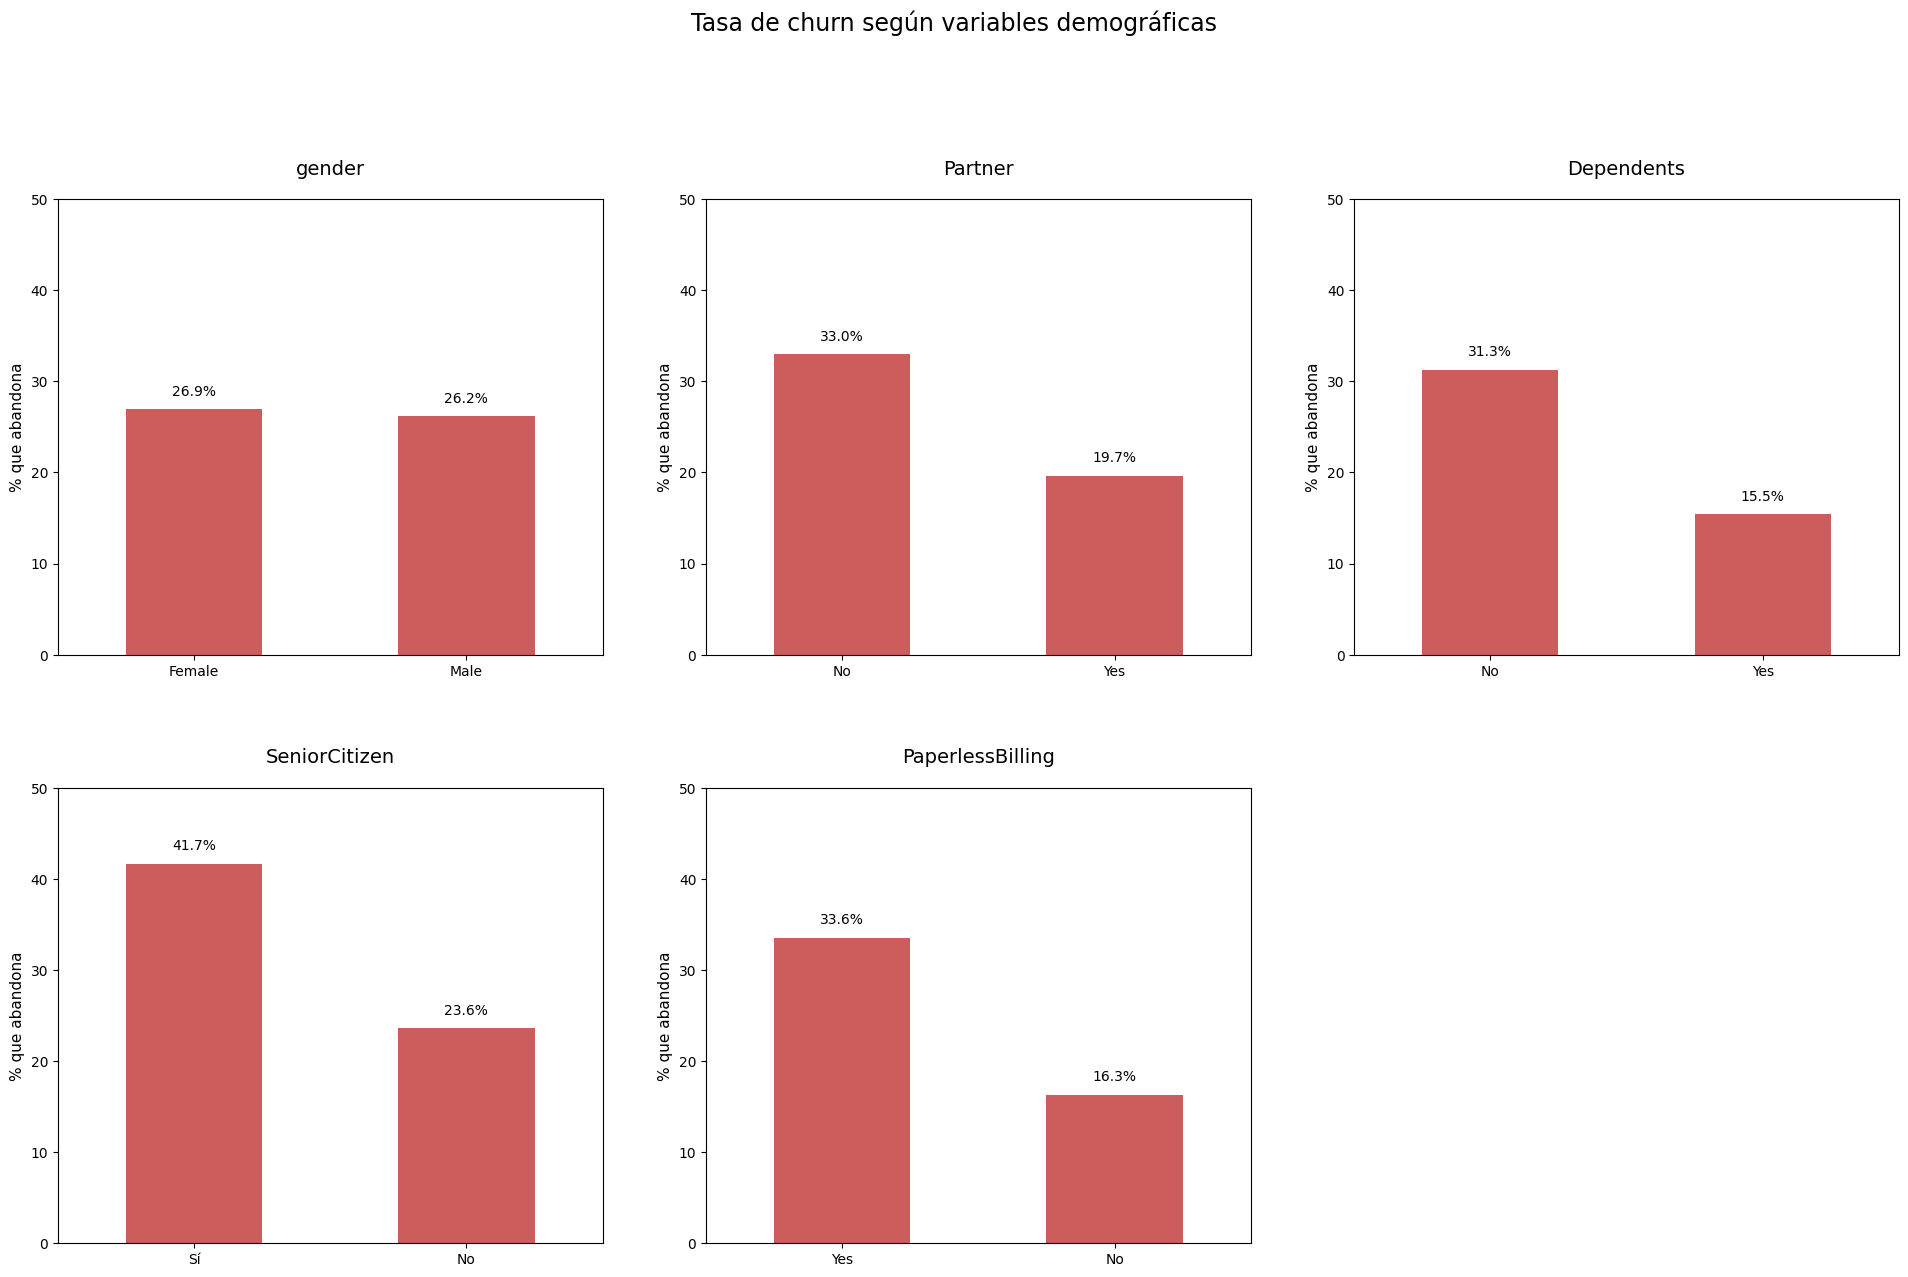

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

variables_demograficas = ['gender', 'Partner', 'Dependents', 'SeniorCitizen', 'PaperlessBilling']

# Creamos una copia solo para graficar, con SeniorCitizen en formato legible
df_grafico = df_clean.copy()
df_grafico['SeniorCitizen'] = df_grafico['SeniorCitizen'].map({0: 'No', 1: 'Sí'})

for i, var in enumerate(variables_demograficas):
    churn_por_categoria = pd.crosstab(df_grafico[var], df_grafico['Churn'], normalize='index') * 100
    churn_por_categoria.columns = ['No', 'Sí']
    tasa_ordenada = churn_por_categoria['Sí'].sort_values(ascending=False)

    tasa_ordenada.plot(kind='bar', color='indianred', ax=axes[i])
    axes[i].set_title(f'{var}', fontsize=14, pad=18)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% que abandona', fontsize=11)
    axes[i].tick_params(axis='x', rotation=0, labelsize=10)
    axes[i].set_ylim(0, 50)

    for j, valor in enumerate(tasa_ordenada):
        axes[i].text(j, valor + 1.5, f'{valor:.1f}%', ha='center', fontsize=10)

# Ocultamos el sexto subplot, ya que solo tenemos 5 variables
axes[5].axis('off')

fig.suptitle('Tasa de churn según variables demográficas', fontsize=17, y=1.01)
plt.tight_layout(pad=4, w_pad=4, h_pad=5)
plt.savefig(f'{ruta_imagenes}imagen_8_demograficas_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

Aquí sí que hay bastante variedad entre unas variables y otras, vamos por partes.

Gender prácticamente no muestra diferencia: 26,9% en mujeres frente a 26,2% en hombres, una diferencia insignificante. Es una variable sin capacidad predictiva relevante, similar a lo que vimos con PhoneService.

Partner y Dependents sí muestran un patrón claro y en la misma dirección: los clientes sin pareja abandonan un 33,0% frente a un 19,7% de los que sí la tienen, y los clientes sin personas dependientes a su cargo abandonan un 31,3% frente a solo un 15,5% de los que sí tienen dependientes. En ambos casos, tener vínculos familiares (pareja o dependientes) se asocia con menor abandono, lo cual tiene sentido intuitivo: suelen ser clientes con una situación más estable y con más razones para mantener el servicio sin interrupciones.

SeniorCitizen muestra una diferencia muy marcada: los clientes mayores de 65 años abandonan un 41,7%, casi el doble que los clientes más jóvenes (23,6%). Es una de las variables demográficas con mayor impacto.

Y PaperlessBilling también destaca bastante: los clientes con facturación electrónica abandonan un 33,6%, frente a solo un 16,3% de quienes reciben factura en papel. Esto podría estar relacionado con el perfil de cliente (quizás los que usan facturación electrónica están más acostumbrados a gestionar todo digitalmente, incluidas las bajas) o simplemente correlacionado con otras variables como el tipo de contrato o el método de pago.

**MEMORIA**

El análisis de las variables demográficas frente al churn mostró resultados heterogéneos. La variable gender no reveló diferencias relevantes entre categorías (26,9% en mujeres frente a 26,2% en hombres), lo que sugiere una baja capacidad explicativa de esta variable respecto al abandono. En cambio, Partner y Dependents mostraron un patrón consistente: los clientes sin pareja y sin personas dependientes a su cargo presentan tasas de churn notablemente superiores (33,0% y 31,3%, respectivamente) frente a quienes sí cuentan con estos vínculos (19,7% y 15,5%), lo que podría asociarse a una mayor estabilidad en la situación personal de estos últimos.

Asimismo, se observó que los clientes de edad avanzada (SeniorCitizen) presentan una tasa de abandono considerablemente más alta (41,7%) que el resto de clientes (23,6%), y que los clientes con facturación electrónica (PaperlessBilling) también muestran una tasa de churn superior (33,6%) frente a quienes reciben factura en papel (16,3%). En conjunto, estos resultados apuntan a que, si bien algunas variables demográficas aportan escasa información, otras como la edad, la situación familiar y el tipo de facturación podrían constituir factores relevantes para la identificación de clientes en riesgo de abandono.

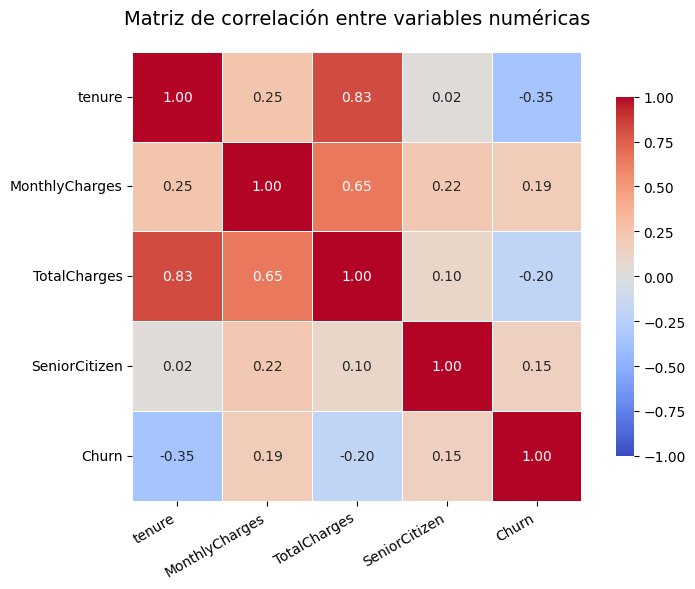

In [ ]:
plt.figure(figsize=(8, 6))

variables_correlacion = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
matriz_corr = df_clean[variables_correlacion].corr()

sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})

plt.title('Matriz de correlación entre variables numéricas', fontsize=14, pad=20)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_9_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

Lo primero que salta a la vista es la correlación muy alta entre tenure y TotalCharges (0,83), y también notable entre MonthlyCharges y TotalCharges (0,65). Esto era esperable, ya que habíamos comentado que TotalCharges se construye básicamente a partir de las otras dos (tenure × MonthlyCharges). Esto es lo que se llama multicolinealidad, y es importante mencionarlo en la memoria porque, si más adelante usas un modelo como la regresión logística, tener variables tan correlacionadas entre sí puede distorsionar la interpretación de sus coeficientes, algo relevante para ti porque tu modelo busca ser explicable.

En cuanto a la relación con Churn, la correlación más fuerte es con tenure (-0,35): el signo negativo confirma lo que vimos en los boxplots, a menor antigüedad, mayor tendencia al abandono. TotalCharges tiene una correlación de -0,20 con Churn (también negativa, en la misma línea), MonthlyCharges tiene una correlación positiva pero débil (0,19), y SeniorCitizen una correlación positiva también débil (0,15).

Un matiz importante que conviene aclarar en tu memoria: esta matriz solo mide relaciones lineales entre variables numéricas, así que variables categóricas como Contract, que vimos que tenían un impacto enorme en el churn, no aparecen aquí porque no son numéricas. Es decir, una correlación "débil" en este cuadro no significa que la variable no importe, solo que no tiene una relación lineal fuerte; el verdadero peso de cada variable se verá con más precisión cuando entrenes los modelos y analices su importancia (algo especialmente relevante dado que tu TFM se centra en explicabilidad).

El análisis de correlación entre las variables numéricas del dataset reveló una fuerte relación lineal entre tenure y TotalCharges (r = 0,83), así como entre MonthlyCharges y TotalCharges (r = 0,65), resultado coherente con la naturaleza de estas variables, dado que TotalCharges se deriva en gran medida del producto entre la antigüedad del cliente y su cargo mensual. Esta elevada colinealidad deberá tenerse en cuenta en fases posteriores del proyecto, especialmente si se emplean modelos sensibles a este fenómeno, como la regresión logística, dado su potencial impacto en la interpretación de los coeficientes del modelo.

En cuanto a la relación con la variable objetivo, tenure presentó la correlación más relevante (r = -0,35), indicando que una menor antigüedad se asocia con una mayor probabilidad de abandono, mientras que TotalCharges, MonthlyCharges y SeniorCitizen mostraron correlaciones más débiles (-0,20, 0,19 y 0,15, respectivamente). Cabe señalar que esta matriz únicamente captura relaciones lineales entre variables numéricas, por lo que variables categóricas con fuerte asociación observada en el análisis previo, como Contract, no quedan reflejadas en este análisis, y su relevancia deberá confirmarse posteriormente a través de las técnicas de interpretabilidad aplicadas sobre los modelos predictivos.

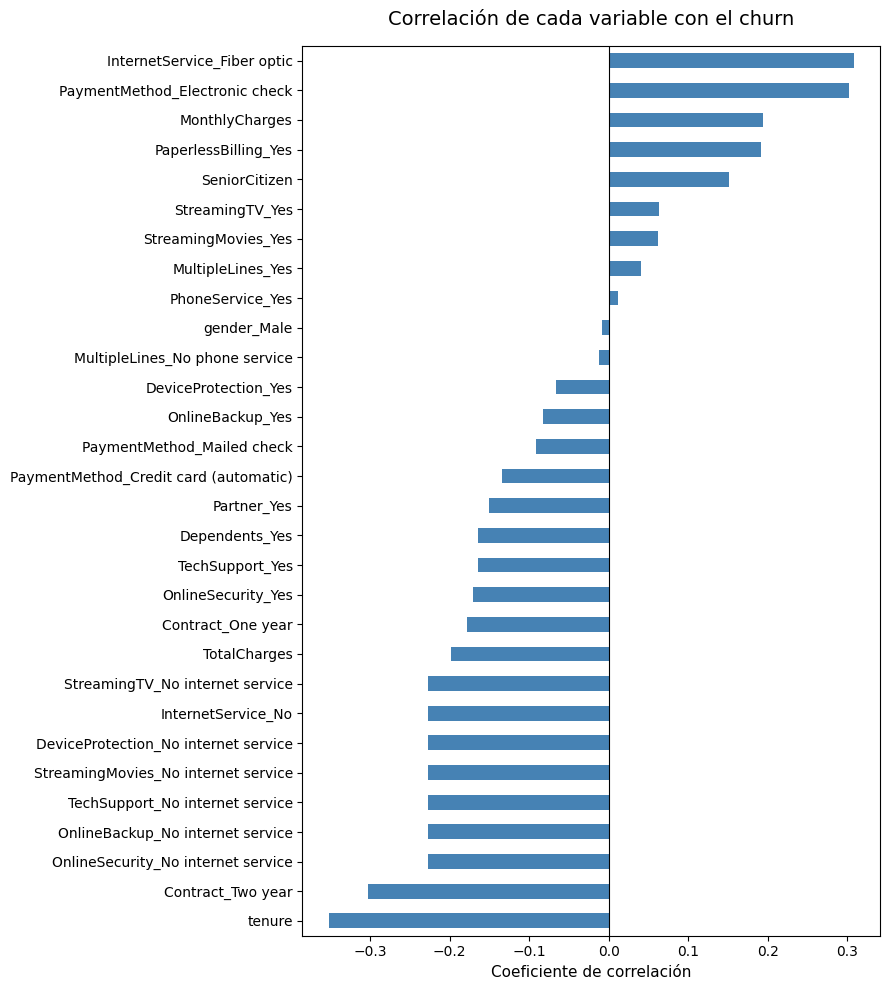

In [ ]:
# Codificamos temporalmente todo el dataset (solo para este análisis, no se guarda)
df_para_correlacion = pd.get_dummies(df_clean, drop_first=True)

# Correlación de cada variable con Churn, ordenada de mayor a menor
correlacion_con_churn = df_para_correlacion.corr()['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(9, 10))
correlacion_con_churn.plot(kind='barh', color='steelblue')
plt.title('Correlación de cada variable con el churn', fontsize=14, pad=15)
plt.xlabel('Coeficiente de correlación', fontsize=11)
plt.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_10_correlacion_todas_variables.png', dpi=300, bbox_inches='tight')
plt.show()

En el lado positivo (mayor correlación con churn = 1), destacan InternetService_Fiber optic y PaymentMethod_Electronic check como las más fuertes, seguidas de MonthlyCharges, PaperlessBilling_Yes y SeniorCitizen. Esto coincide exactamente con lo que ya habíamos visto: fibra óptica, cheque electrónico, cargos altos, facturación electrónica y ser cliente senior se asocian con mayor abandono.

En el lado negativo (mayor correlación con la permanencia, churn = 0), destaca con diferencia tenure, seguida de Contract_Two year y varias variables relacionadas con "No internet service" (OnlineSecurity_No internet service, StreamingTV_No internet service, etc.). Aquí hay un detalle importante que vale la pena que entiendas: todas esas variables de "No internet service" están correlacionadas de forma muy parecida entre sí porque, en realidad, representan exactamente al mismo grupo de clientes (los que no tienen internet contratado), así que no son seis señales distintas, sino prácticamente la misma señal repetida seis veces. Es otro ejemplo de la colinealidad de la que hablamos antes, y es bueno mencionarlo en la memoria como una limitación a tener en cuenta.

También aparecen con correlación negativa moderada TotalCharges, Contract_One year, OnlineSecurity_Yes, TechSupport_Yes, Dependents_Yes y Partner_Yes, todas coherentes con el análisis categórico que hicimos antes.

**MEMORIA**

Finalmente, se calculó la correlación de todas las variables del dataset, incluidas las categóricas previamente codificadas mediante one-hot encoding, con la variable objetivo Churn. Este análisis confirmó los hallazgos obtenidos en las secciones anteriores del EDA: las variables con mayor correlación positiva con el abandono fueron InternetService_Fiber optic, PaymentMethod_Electronic check, MonthlyCharges, PaperlessBilling_Yes y SeniorCitizen, mientras que las de mayor correlación negativa (es decir, asociadas a la permanencia del cliente) fueron tenure, Contract_Two year y diversas variables relacionadas con la ausencia de servicio de internet. Cabe destacar que estas últimas variables, al derivarse de un mismo subconjunto de clientes (aquellos sin internet contratado), presentan una elevada colinealidad entre sí, por lo que deberán interpretarse con cautela en las fases posteriores del proyecto. En conjunto, este análisis refuerza la relevancia de variables como el tipo de contrato, la antigüedad del cliente, el tipo de servicio de internet y el método de pago como factores clave para la predicción del abandono.

**resumen- conclusion EDA-MEMORIA**

El análisis exploratorio de datos permitió identificar patrones relevantes en el comportamiento de los clientes de la compañía y su relación con el abandono del servicio. En primer lugar, se comprobó que la variable objetivo presenta un desbalance moderado, con un 26,5% de clientes que cancelaron el servicio frente a un 73,5% que permanecen activos, aspecto que deberá ser considerado en la fase de modelado. Respecto a las variables numéricas, se observó que los clientes con menor antigüedad y mayores cargos mensuales presentan una mayor propensión al abandono, mientras que el importe total facturado resulta ser considerablemente menor entre los clientes que cancelan, como consecuencia lógica de su corta permanencia en la compañía.

El análisis de las variables categóricas reveló que el tipo de contrato constituye uno de los factores más determinantes del abandono, con una tasa de churn del 42,7% entre los clientes con contrato mensual, frente a solo un 2,8% entre aquellos con contrato de dos años. De manera similar, el tipo de servicio de internet y el método de pago mostraron diferencias notables, destacando una mayor tasa de abandono entre los clientes con fibra óptica y entre quienes utilizan el cheque electrónico como forma de pago. En el ámbito demográfico, se identificó una mayor propensión al abandono entre los clientes de edad avanzada y entre aquellos sin pareja o personas dependientes a su cargo, mientras que variables como el género o la disponibilidad de servicio telefónico no mostraron diferencias relevantes.

Por último, el análisis de correlaciones puso de manifiesto una elevada colinealidad entre las variables tenure, MonthlyCharges y TotalCharges, así como entre las distintas variables asociadas a la ausencia de servicio de internet, aspecto que deberá tenerse en cuenta en las fases posteriores del proyecto. En conjunto, los resultados del análisis exploratorio permiten anticipar que variables como el tipo de contrato, la antigüedad del cliente, el tipo de servicio de internet, el método de pago y determinadas características demográficas jugarán un papel relevante en la construcción del modelo predictivo de abandono, proporcionando además una primera base interpretativa que resultará de utilidad para el posterior análisis de explicabilidad del modelo.

**3. Preprocesamiento**

**División train/test**

In [ ]:
from sklearn.model_selection import train_test_split

# Separamos variables predictoras (X) y variable objetivo (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# División estratificada para mantener la proporción de churn en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño train:', X_train.shape)
print('Tamaño test:', X_test.shape)
print('% churn en train:', y_train.mean() * 100)
print('% churn en test:', y_test.mean() * 100)

Tamaño train: (5634, 19)
Tamaño test: (1409, 19)
% churn en train: 26.53532126375577
% churn en test: 26.54364797728886


Hacemos el split antes de codificar categóricas, escalar y tratar el desbalance, porque cualquier transformación que "aprenda" de los datos (como calcular la media/desviación para escalar, o generar muestras sintéticas con SMOTE) debe ajustarse únicamente con el conjunto de entrenamiento, para evitar fuga de información (data leakage) hacia el test.

Usamos stratify=y porque el churn está desbalanceado (~27%), así garantizamos que esa proporción se mantenga igual en train y en test. Y fijamos random_state=42 para que el split sea reproducible.

**Codificación variables categóricas**

In [ ]:
# Variables Binarias
mapa_binarias = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1}
}

X_train = X_train.replace(mapa_binarias)
X_test = X_test.replace(mapa_binarias)

X_train[list(mapa_binarias.keys())].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
3738,1,0,0,0,0
3151,1,1,1,1,0
4860,1,1,1,0,0
3867,0,1,0,1,1
3810,1,1,1,1,0


In [ ]:
# Variables con más de dos categorías -> one-hot encoding

cols_multicategoria = X_train.select_dtypes(include='object').columns.tolist()
print('Columnas a codificar con one-hot:', cols_multicategoria)

X_train = pd.get_dummies(X_train, columns=cols_multicategoria, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_multicategoria, drop_first=True)

# 3) Alineamos las columnas de test con las de train (por si falta alguna categoría en test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 4) Convertimos las columnas booleanas (True/False) a enteros (1/0)
X_train = X_train.astype({col: int for col in X_train.select_dtypes(include='bool').columns})
X_test = X_test.astype({col: int for col in X_test.select_dtypes(include='bool').columns})

print('Columnas train:', X_train.shape[1])
print('Columnas test:', X_test.shape[1])
X_train.head()

Columnas a codificar con one-hot: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Columnas train: 30
Columnas test: 30


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,35,0,0,49.20,1701.65,1,...,0,0,1,0,1,0,0,0,1,0
3151,1,0,1,1,15,1,0,75.10,1151.55,0,...,0,0,0,0,0,0,0,0,0,1
4860,1,0,1,1,13,0,0,40.55,590.35,1,...,1,0,0,0,0,0,1,0,0,1
3867,0,0,1,0,26,1,1,73.50,1905.70,0,...,0,0,1,0,1,0,1,1,0,0
3810,1,0,1,1,1,1,0,44.55,44.55,0,...,0,0,0,0,0,0,0,0,1,0


La solución es el one-hot encoding: por cada categoría se crea una columna nueva con 0 o 1 indicando si el cliente pertenece a esa categoría o no.

**Escalado variables númericas**

Escalar pone todas las variables numéricas en un rango comparable para que compitan en igualdad de condiciones. (Nota: si al final usas solo modelos de árboles, como Random Forest o XGBoost, este paso no es estrictamente necesario, pero no hace ningún daño tenerlo y te da flexibilidad para probar otros modelos).
¿Qué variable usamos? La técnica más común es StandardScaler, que transforma cada valor así: resta la media y divide entre la desviación estándar, de forma que la variable resultante tenga media 0 y desviación 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Columnas numéricas continuas a escalar (SeniorCitizen ya es 0/1, no hace falta escalarla)
cols_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# IMPORTANTE: ajustamos (fit) el scaler SOLO con train, para no filtrar información del test
X_train[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])

# En test solo transformamos, usando la media/desviación ya aprendidas de train
X_test[cols_numericas] = scaler.transform(X_test[cols_numericas])

X_train[cols_numericas].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


El punto clave que debes explicar en tu memoria: usamos fit_transform en X_train (el scaler "aprende" la media y desviación estándar de esos datos) pero solo transform en X_test (aplicamos esos mismos valores aprendidos, sin recalcular nada con el test). Si escalaras ambos conjuntos juntos, o ajustaras el scaler con todo el dataset antes del split, estarías filtrando información del test hacia el entrenamiento, lo cual es un error metodológico común (data leakage) y haría que tu evaluación del modelo fuera artificialmente optimista.

Ahora tenure, MonthlyCharges y TotalCharges tienen media cercana a 0.

**Tratamiento del desbalance de clases**

 churn representa aproximadamente el 26,5% de los clientes (frente a un 73,5% que no hace churn). No es un desbalance extremo, pero sí puede hacer que un modelo "vago" logre buena accuracy simplemente prediciendo casi siempre "No churn", sin aprender realmente a detectar a los clientes que se van.

Opción A: class_weight='balanced' — no tocas los datos, simplemente le dices al algoritmo (por ejemplo, LogisticRegression(class_weight='balanced') o RandomForestClassifier(class_weight='balanced')) que penalice más los errores sobre la clase minoritaria (churn=1). Es la opción más sencilla, no distorsiona los datos originales y es totalmente compatible con explicabilidad (SHAP, LIME, importancia de variables), porque el dataset sigue siendo el real.

Opción B: SMOTE — genera ejemplos sintéticos de la clase minoritaria (clientes que hacen churn) para equilibrar las proporciones antes de entrenar. Es más agresivo y a veces mejora el recall, pero añade complejidad y "inventa" datos que no existieron realmente, lo cual conviene mencionar y justificar bien en la memoria si lo usas.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculamos el peso que le correspondería a cada clase según su frecuencia
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
peso_clases = dict(zip(np.unique(y_train), pesos))
print('Pesos por clase (0=No churn, 1=Churn):', peso_clases)

# Para XGBoost, que no usa class_weight sino scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight (para XGBoost):', scale_pos_weight)

Pesos por clase (0=No churn, 1=Churn): {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}
scale_pos_weight (para XGBoost): 2.768561872909699


In [ ]:
# Guardamos los conjuntos ya preprocesados en Drive
ruta_salida = '/content/drive/MyDrive/VIU_Máster_en_Data_Analytics/TFM /'

X_train.to_csv(ruta_salida + 'X_train.csv', index=False)
X_test.to_csv(ruta_salida + 'X_test.csv', index=False)
y_train.to_csv(ruta_salida + 'y_train.csv', index=False)
y_test.to_csv(ruta_salida + 'y_test.csv', index=False)

print('Archivos guardados correctamente en Drive.')

Archivos guardados correctamente en Drive.


Repasemos rápido todo lo que hiciste, para que tengas claro el hilo completo: primero limpiaste el dataset (eliminaste customerID, corregiste el tipo de TotalCharges e imputaste los 11 valores nulos con 0 por su lógica de negocio), después codificaste la variable objetivo Churn a 0/1, dividiste los datos en train/test de forma estratificada para preservar la proporción de churn, codificaste las variables categóricas (binarias con mapeo directo, multicategoría con one-hot encoding), escalaste las variables numéricas continuas con StandardScaler ajustado solo en train, calculaste los pesos de clase para tratar el desbalance en la futura fase de modelado, y finalmente guardaste los cuatro conjuntos resultantes en Drive.
Es un flujo bastante completo y bien justificado metodológicamente, con las decisiones típicas que se esperan en un TFM (evitar data leakage, justificar imputaciones con lógica de negocio, tratar el desbalance de forma explícita).


TEXTO PARA MEMORIA

Una vez finalizado el análisis exploratorio del dataset Telco Customer Churn, se procedió a preparar los datos para su uso en los modelos predictivos. En primer lugar, se realizó una limpieza básica de la información. Se eliminó la variable customerID, ya que se trata únicamente de un identificador de cliente sin ningún valor predictivo para el modelo. También se corrigió el tipo de dato de la variable TotalCharges, que originalmente estaba almacenada como texto en lugar de como número.

Al realizar esta conversión se detectaron 11 registros sin valor, todos ellos correspondientes a clientes con una antigüedad de cero meses, es decir, clientes recién incorporados que todavía no habían generado facturación acumulada. Por este motivo, se decidió sustituir estos valores por cero, en lugar de eliminarlos, ya que resultaba la opción más coherente con la realidad de estos clientes y permitía conservar su información para el análisis.

A continuación, se transformó la variable objetivo Churn, pasando sus valores de texto (Yes/No) a valores numéricos (1/0), paso necesario para poder entrenar los modelos y calcular sus métricas de rendimiento. Posteriormente, el conjunto de datos se dividió en dos subconjuntos, uno de entrenamiento y otro de prueba, utilizando una proporción de 80% y 20% respectivamente. Esta división se realizó de forma estratificada, con el fin de que la proporción de clientes que abandonan la compañía se mantuviera igual en ambos subconjuntos, evitando así que uno de ellos quedara sesgado respecto al otro.

Con los datos ya divididos, se llevó a cabo la codificación de las variables categóricas, necesaria porque los modelos de aprendizaje automático únicamente pueden trabajar con valores numéricos. Las variables con solo dos categorías, como el género o si el cliente tiene pareja, se transformaron directamente a valores de 0 y 1. Las variables con más de dos categorías, como el tipo de contrato o el método de pago, se codificaron mediante la técnica de one-hot encoding, que consiste en crear una columna independiente para cada categoría, indicando con un 1 o un 0 si el cliente pertenece o no a ella. Esta técnica evita que el modelo interprete relaciones de orden entre categorías que, en realidad, no existen.

Después, se escalaron las variables numéricas continuas, tenure, MonthlyCharges y TotalCharges, mediante la técnica de estandarización, que ajusta los valores para que todos se encuentren en una escala comparable. Este paso resulta especialmente importante para modelos que son sensibles a la magnitud de los datos, como la regresión logística. Cabe destacar que tanto en este paso como en el escalado, todos los ajustes se calcularon únicamente a partir del conjunto de entrenamiento y después se aplicaron al conjunto de prueba, con el objetivo de evitar una fuga de información entre ambos conjuntos que pudiera generar una evaluación poco realista del modelo.

Por último, se abordó el desbalance existente en la variable objetivo, dado que únicamente un 26,5% de los clientes de la muestra habían abandonado la compañía frente a un 73,5% que continuaban activos. Para compensar esta diferencia, se calcularon los pesos correspondientes a cada clase, que serán utilizados posteriormente durante el entrenamiento de los modelos para que estos presten una atención adecuada a los clientes que sí abandonan el servicio, evitando así que el modelo favorezca de forma injusta a la clase mayoritaria. Finalmente, los conjuntos resultantes de todo este proceso se almacenaron en Google Drive, quedando así preparados para su uso directo en la siguiente fase del proyecto, correspondiente al desarrollo y evaluación de los modelos predictivos.

**MODELO DE PREDICCIÓN**

In [ ]:
# ============================
# 4. MODELADO
# ============================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# --- Modelo base (baseline) ---
# strategy='most_frequent' predice siempre la clase mayoritaria (No abandona)
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print("=== Baseline (predice siempre la clase mayoritaria) ===")
print(classification_report(y_test, y_pred_baseline, target_names=['No abandona', 'Sí abandona']))

=== Baseline (predice siempre la clase mayoritaria) ===
              precision    recall  f1-score   support

 No abandona       0.73      1.00      0.85      1035
 Sí abandona       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ============================
# MODELADO REGRESIÓN LOGÍSTICA
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt

# --- Modelo 1: Regresión Logística ---
modelo_log = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_log.fit(X_train, y_train)

# Predicciones
y_pred_log = modelo_log.predict(X_test)
y_proba_log = modelo_log.predict_proba(X_test)[:, 1]  # probabilidad de la clase "Sí abandona"

# Métricas
print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_log, target_names=['No abandona', 'Sí abandona']))

auc_log = roc_auc_score(y_test, y_proba_log)
print(f"AUC-ROC: {auc_log:.3f}")

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_log)
print("Matriz de confusión:")
print(matriz)

=== Regresión Logística ===
              precision    recall  f1-score   support

 No abandona       0.90      0.72      0.80      1035
 Sí abandona       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.842
Matriz de confusión:
[[747 288]
 [ 81 293]]


**Interpretación de los resultados**

Baseline (DummyClassifier): como era de esperar, este modelo predice siempre "No abandona" para todos los clientes. Por eso tiene un recall de 1.00 (100%) en la clase "No abandona" —acierta siempre, porque nunca dice otra cosa— pero un recall de 0.00 en "Sí abandona": no detecta ni un solo cliente que realmente se vaya. Fíjate que, aun así, tiene una accuracy del 73%, que suena bien a primera vista, pero es completamente engañosa, porque ese número solo refleja que el 73% de los clientes en efecto no abandonan, no que el modelo esté haciendo nada inteligente. Esto es exactamente el tipo de comparación que querías tener: te sirve para demostrar en la memoria que la accuracy sola no es una métrica fiable en un problema desbalanceado como este.

**Regresión Logística:** aquí el panorama cambia bastante. La accuracy general es del 74%, muy similar a la del baseline, pero lo importante está en el detalle: el recall de "Sí abandona" sube a 0.78, es decir, el modelo ahora identifica correctamente a 293 de los 374 clientes que realmente abandonaron en el conjunto de test (puedes verlo en la matriz de confusión: 293 verdaderos positivos, frente a 81 que se le escapan). Es una mejora enorme respecto al 0% del baseline. A cambio, la precisión de esa misma clase es de 0.50, lo que significa que, de cada 10 clientes que el modelo marca como "va a abandonar", solo 5 realmente lo hacen (hay 288 falsos positivos).

Este es el trade-off típico de aplicar class_weight='balanced': el modelo se vuelve mucho más sensible a detectar la clase minoritaria, a costa de generar más falsas alarmas. Por último, el AUC-ROC de 0.842 es un buen valor (por encima de 0.8 se suele considerar una buena capacidad de discriminación), y confirma que el modelo, en términos generales, distingue razonablemente bien entre quien abandona y quien no, independientemente del umbral de decisión que se use.
En resumen: el baseline te sirve como "suelo" de comparación (0% de detección), y la Regresión Logística ya demuestra un valor real, priorizando detectar a los clientes en riesgo (recall alto) aunque eso implique contactar de más a algunos que en realidad no se iban a ir, algo que en el contexto de negocio (retener clientes) suele ser un trade-off aceptable.

**Párrafo para la memoria**

Como primer paso de la fase de modelado, se entrenó un modelo base (baseline) mediante un clasificador que predice siempre la clase mayoritaria, con el fin de establecer un punto de referencia mínimo frente al cual comparar el rendimiento de los modelos posteriores. Este modelo obtuvo una exactitud (accuracy) del 73%, resultado que, sin embargo, resulta engañoso, ya que su capacidad para detectar a los clientes que efectivamente abandonan (recall) fue del 0%, evidenciando la limitación de la accuracy como métrica única en un problema con clases desbalanceadas.

A continuación, se entrenó un modelo de Regresión Logística, incorporando una ponderación de clases (class_weight balanceado) para compensar la menor representación de los clientes que abandonan. Este modelo alcanzó una exactitud similar a la del baseline (74%), pero mostró una mejora sustancial en la detección de la clase de interés, con un recall del 78% para los clientes que cancelan el servicio, así como un área bajo la curva ROC (AUC-ROC) de 0,842, indicativo de una buena capacidad de discriminación entre ambas clases. Como contrapartida, la precisión obtenida para dicha clase fue del 50%, lo que refleja un aumento en el número de falsos positivos, un compromiso habitual al priorizar la identificación de clientes en riesgo de abandono frente a la minimización de falsas alarmas.

In [ ]:
# ============================
# MODELADO - ÁRBOL DE DECISIÓN
# ============================

from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=5  # limitamos la profundidad para evitar sobreajuste extremo
)
modelo_arbol.fit(X_train, y_train)

# Predicciones
y_pred_arbol = modelo_arbol.predict(X_test)
y_proba_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

# Métricas
print("=== Árbol de Decisión ===")
print(classification_report(y_test, y_pred_arbol, target_names=['No abandona', 'Sí abandona']))

auc_arbol = roc_auc_score(y_test, y_proba_arbol)
print(f"AUC-ROC: {auc_arbol:.3f}")

matriz_arbol = confusion_matrix(y_test, y_pred_arbol)
print("Matriz de confusión:")
print(matriz_arbol)

=== Árbol de Decisión ===
              precision    recall  f1-score   support

 No abandona       0.91      0.71      0.80      1035
 Sí abandona       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409

AUC-ROC: 0.831
Matriz de confusión:
[[733 302]
 [ 72 302]]


**Interpretación**

El Árbol de Decisión, sorprendentemente, tiene el recall más alto de todos los modelos hasta ahora: 0.81 en la clase "Sí abandona", superando incluso a la Regresión Logística (0.78). Mirando la matriz de confusión, detecta a 302 de los 374 clientes que realmente abandonan, dejando escapar solo 72, el número más bajo de falsos negativos de toda la comparación. Su AUC-ROC (0.831) también es bastante competitivo, quedando entre Random Forest y XGBoost.

Eso sí, tiene el mismo "precio" que pagaba la Regresión Logística: una precisión de 0.50 en esa clase (la mitad de sus predicciones de "abandona" son en realidad falsas alarmas, 302 falsos positivos), y la accuracy más baja del grupo de modelos "reales" (0.73, prácticamente igual que el baseline). Esto tiene sentido con lo que comentamos antes: al limitar la profundidad a 5 niveles y aplicar class_weight='balanced', el árbol prioriza mucho la detección de la clase minoritaria, a costa de generar bastantes falsos positivos, un patrón parecido al de la Regresión Logística pero incluso un poco más marcado en el recall.

Se ve muy claro un patrón consistente en los cuatro modelos "reales": a medida que sube la accuracy, baja el recall de la clase que más te interesa. El Árbol de Decisión y la Regresión Logística son los dos modelos que mejor cumplen el objetivo de "detectar al mayor número de clientes en riesgo", con la Regresión Logística ligeramente por delante gracias a su mejor AUC-ROC.

**Párrafo para la memoria**

 En segundo lugar, se entrenó un Árbol de Decisión, limitando su profundidad máxima a cinco niveles con el fin de evitar un sobreajuste excesivo, dada la tendencia natural de este tipo de modelos a memorizar el conjunto de entrenamiento cuando no se restringe su crecimiento.

El modelo, entrenado igualmente con ponderación de clases, obtuvo el recall más alto de toda la comparación para la clase de clientes que abandonan (81%), superando incluso a la Regresión Logística, así como un área bajo la curva ROC de 0,831. No obstante, presentó una precisión del 50% para dicha clase y la accuracy más baja entre los modelos evaluados (73%), evidenciando el mismo compromiso entre recall y precisión observado en el resto de modelos.

In [ ]:
# ============================
# MODELADO - RANDOM FOREST
# ============================

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    max_depth=None
)
modelo_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Métricas
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No abandona', 'Sí abandona']))

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC-ROC: {auc_rf:.3f}")

matriz_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de confusión:")
print(matriz_rf)

=== Random Forest ===
              precision    recall  f1-score   support

 No abandona       0.83      0.90      0.86      1035
 Sí abandona       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC: 0.829
Matriz de confusión:
[[928 107]
 [192 182]]


**Interpretación**

Random Forest tiene la accuracy más alta de los tres modelos hasta ahora (79%, frente al 74% de la Regresión Logística), y también mejora bastante la precisión de la clase "Sí abandona" (0.63 frente a 0.50). Es decir, cuando este modelo dice que un cliente va a abandonar, acierta más veces que la Regresión Logística.

Sin embargo, aquí está el matiz importante: el recall de "Sí abandona" baja considerablemente, a 0.49, frente al 0.78 que lograba la Regresión Logística. Mirando la matriz de confusión, Random Forest solo detecta a 182 de los 374 clientes que realmente abandonan, dejando escapar 192 (casi la mitad), mientras que la Regresión Logística solo dejaba escapar 81. El AUC-ROC también es ligeramente inferior (0.829 frente a 0.842), aunque la diferencia ahí es pequeña.

Esto ilustra un trade-off clásico en estos problemas: Random Forest, incluso con class_weight='balanced', tiende a ser más "conservador" a la hora de predecir la clase minoritaria que la Regresión Logística, porque construye sus reglas de decisión buscando patrones que maximicen el acierto global entre muchos árboles, lo cual favorece un poco más a la clase mayoritaria. En términos de negocio, esto importa mucho: si el objetivo principal es detectar cuantos más clientes en riesgo mejor (aunque eso implique alguna falsa alarma de más), la Regresión Logística está cumpliendo mejor ese objetivo concreto hasta ahora, pese a que Random Forest "parece" mejor si solo miras la accuracy general. Esta es exactamente la clase de matiz que vale la pena resaltar en tu memoria: la métrica que hay que priorizar depende del objetivo de negocio, no solo del número que more alto salga.
Aún nos falta ver cómo se comporta XGBoost antes de decidir cuál es el mejor modelo final.

**Párrafo para la memoria**

En tercer lugar se entrenó un modelo de Random Forest también con ponderación de clases para compensar el desbalance existente en la variable objetivo. Este modelo obtuvo una acurracy del 79%, superior a la alcanzada por la Regresión Logística, así como una mayor precisión en la identificación de los clientes que abandonan (63% frente al 50% de los modelos anteriores). No obstante, su capacidad para detectar efectivamente a dichos clientes fue notablemente inferior, con un recall del 49%, frente al 78% obtenido por la Regresión Logística y el 80% del arbol de decisión, dejando sin identificar a un porcentaje considerable de clientes en riesgo real de abandono.

 El área bajo la curva ROC fue de 0,829, un valor ligeramente inferior al de los modelos anteriores. Estos resultados evidencian un compromiso relevante entre precisión y capacidad de detección (recall), que deberá tenerse en cuenta al seleccionar el modelo más adecuado en función del objetivo prioritario del negocio, orientado a identificar de forma temprana al mayor número posible de clientes con riesgo de abandono.

In [ ]:
# ============================
# MODELADO - GRADIENT BOOSTING (solo para comparar, exploratorio)
# ============================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# GradientBoostingClassifier no admite class_weight, así que calculamos
# un peso por muestra equivalente al balanceo que usamos en los otros modelos
pesos_muestra = compute_sample_weight(class_weight='balanced', y=y_train)

modelo_gb = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)
modelo_gb.fit(X_train, y_train, sample_weight=pesos_muestra)

# Predicciones
y_pred_gb = modelo_gb.predict(X_test)
y_proba_gb = modelo_gb.predict_proba(X_test)[:, 1]

# Métricas
print("=== Gradient Boosting (exploratorio) ===")
print(classification_report(y_test, y_pred_gb, target_names=['No abandona', 'Sí abandona']))

auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f"AUC-ROC: {auc_gb:.3f}")

matriz_gb = confusion_matrix(y_test, y_pred_gb)
print("Matriz de confusión:")
print(matriz_gb)

=== Gradient Boosting (exploratorio) ===
              precision    recall  f1-score   support

 No abandona       0.90      0.73      0.81      1035
 Sí abandona       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

AUC-ROC: 0.839
Matriz de confusión:
[[753 282]
 [ 82 292]]


Interesante, este resultado es prácticamente un "empate técnico" con la Regresión Logística. Fíjate en los números: recall de 0.78 en "Sí abandona" (idéntico al de la Regresión Logística), precisión de 0.51 (casi igual, 0.50), accuracy de 0.74 (igual) y AUC-ROC de 0.839 (muy cerca del 0.842 de la Regresión Logística, la diferencia es mínima). En la matriz de confusión detecta a 292 de los 374 clientes que abandonan, dejando escapar 82, un resultado prácticamente calcado al de la Regresión Logística (que dejaba escapar 81).
Esto tiene su lógica: como usamos pesos por muestra equivalentes al balanceo de clases, y Gradient Boosting también construye su modelo optimizando de forma iterativa el error, termina llegando a una solución muy parecida a la de la Regresión Logística en cuanto a comportamiento frente al desbalance, aunque por un camino distinto. Y comp16arándolo con XGBoost (su "hermano" más optimizado), aquí el modelo clásico queda mejor en recall (0.78 frente a 0.62) y en AUC (0.839 frente a 0.812), lo cual es un dato curioso porque uno podría esperar que la versión "mejorada" superara siempre a la clásica, y aquí no ha sido así, al menos con los hiperparámetros por defecto que usamos.

**Párrafo para la memoria**

En cuarto lugar, se entrenó un modelo de Gradient Boosting clásico, empleando en este caso una ponderación por muestra (sample weight) equivalente al balanceo de clases utilizado en los modelos anteriores, dado que esta implementación no admite directamente el parámetro class_weight. El modelo obtuvo una acurracy del 74%, un recall del 78% y una precisión del 51% para la clase de clientes que abandonan, junto con un área bajo la curva ROC de 0,839. Estos resultados resultaron prácticamente equivalentes a los obtenidos por la Regresión Logística, y notablemente superiores, en términos de recall y AUC-ROC, a los alcanzados por XGBoost, su versión optimizada. Este hallazgo resulta interesante, ya que evidencia que una mayor sofisticación algorítmica no garantiza necesariamente un mejor rendimiento para todas las métricas, y refuerza la importancia de comparar empíricamente distintos modelos antes de seleccionar el más adecuado para el objetivo del proyecto.

In [ ]:
# ============================
# MODELADO - XGBOOST
# ============================

from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
modelo_xgb.fit(X_train, y_train)

# Predicciones
y_pred_xgb = modelo_xgb.predict(X_test)
y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Métricas
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No abandona', 'Sí abandona']))

auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"AUC-ROC: {auc_xgb:.3f}")

matriz_xgb = confusion_matrix(y_test, y_pred_xgb)
print("Matriz de confusión:")
print(matriz_xgb)

=== XGBoost ===
              precision    recall  f1-score   support

 No abandona       0.85      0.81      0.83      1035
 Sí abandona       0.54      0.62      0.57       374

    accuracy                           0.76      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409

AUC-ROC: 0.812
Matriz de confusión:
[[835 200]
 [143 231]]


Interpretación de XGBoost

XGBoost queda en una posición intermedia entre los otros dos modelos: tiene una accuracy del 76% (entre el 74% de la Regresión Logística y el 79% de Random Forest), y en la clase "Sí abandona" logra un recall de 0.62 y una precisión de 0.54. Es decir, detecta a 231 de los 374 clientes que realmente abandonan (dejando escapar 143), un resultado mejor que Random Forest (que dejaba escapar 192) pero peor que la Regresión Logística (que solo dejaba escapar 81). Su AUC-ROC es 0.812, el más bajo de los tres modelos "reales", aunque la diferencia con los otros no es enorme.

Viendo la tabla completa, se confirma el patrón que empezamos a notar con Random Forest: a medida que sube la accuracy y la precisión, baja el recall de la clase que más te interesa detectar. La Regresión Logística es, hasta ahora, el modelo que mejor cumple el objetivo de negocio de "detectar cuantos más clientes en riesgo, mejor" (recall más alto y también el mejor AUC-ROC), aunque a costa de más falsas alarmas. Random Forest es el más "equilibrado" en términos de accuracy/precisión, pero el que peor detecta a los clientes que realmente se van. XGBoost queda en un punto medio entre ambos extremos.
Esto no significa necesariamente que la Regresión Logística sea "el ganador final": con Random Forest y XGBoost normalmente se puede ajustar el umbral de decisión (por defecto es 0.5, pero se puede bajar para priorizar más el recall) o afinar hiperparámetros para mejorar su recall sin sacrificar tanto la precisión. Es una decisión que conviene tomar con calma antes de cerrar la fase de modelado

**MEMORIA**

En quinto lugar, se entrenó un modelo XGBoost, utilizando en este caso el parámetro scale_pos_weight para compensar el desbalance de clases, dado que este algoritmo no admite directamente la ponderación mediante class_weight.

El modelo obtuvo una acurracy del 76%, con un recall del 62% y una precisión del 54% para la clase de clientes que abandonan, situándose en una posición intermedia en cuanto a recall respecto al resto de modelos : por debajo del grupo formado por la Regresión Logística, el Árbol de Decisión y Gradient Boosting (con recalls entre el 78% y el 81%), pero por encima de Random Forest (49%). No obstante, XGBoost presentó el área bajo la curva ROC más baja de todo el conjunto de modelos evaluados (0,812).






Al comparar los tres modelos entrenados, se observa un compromiso consistente entre la capacidad de detección de clientes en riesgo de abandono (recall) y la precisión de dicha detección. La Regresión Logística fue el modelo que mostró la mayor capacidad para identificar correctamente a los clientes que abandonan (recall del 78%) y el mejor área bajo la curva ROC (0,842), mientras que Random Forest priorizó la precisión y la exactitud general en detrimento del recall, y XGBoost se situó en una posición intermedia entre ambos. Esta comparación pone de manifiesto que la elección del modelo más adecuado no debe basarse únicamente en la exactitud global, sino que debe considerarse en función del objetivo prioritario del negocio, orientado en este caso a maximizar la detección temprana de clientes en riesgo de abandono.

**Párrafo de conclusión general (actualizado)**

En conjunto, la comparación de los cinco modelos entrenados confirma que no existe un modelo claramente superior en todas las métricas, sino que la elección más adecuada depende del objetivo prioritario del análisis. El Árbol de Decisión, la Regresión Logística y el Gradient Boosting resultaron ser los modelos con mayor capacidad de detección de clientes en riesgo de abandono, con recalls entre el 78% y el 81% y valores de AUC-ROC superiores a 0,83, mientras que Random Forest ofreció la mayor exactitud y precisión general, a costa de una menor sensibilidad hacia la clase minoritaria, y XGBoost se situó en una posición intermedia entre ambos grupos. Esta comparación pone de relieve la importancia de seleccionar la métrica de evaluación en función de las necesidades reales del negocio, priorizando en este caso la capacidad de identificar tempranamente a los clientes con mayor probabilidad de abandono.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Diccionario con las predicciones y probabilidades de cada modelo ya entrenado
resultados = {
    'Baseline': {'y_pred': y_pred_baseline, 'y_proba': None},
    'Regresión Logística': {'y_pred': y_pred_log, 'y_proba': y_proba_log},
    'Árbol de Decisión': {'y_pred': y_pred_arbol, 'y_proba': y_proba_arbol},
    'Random Forest': {'y_pred': y_pred_rf, 'y_proba': y_proba_rf},
    'Gradient Boosting': {'y_pred': y_pred_gb, 'y_proba': y_proba_gb},
    'XGBoost': {'y_pred': y_pred_xgb, 'y_proba': y_proba_xgb},
}

filas = []
for nombre, datos in resultados.items():
    y_pred = datos['y_pred']
    y_proba = datos['y_proba']
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Sí abandona)': precision_score(y_test, y_pred),
        'Recall (Sí abandona)': recall_score(y_test, y_pred),
        'F1-score (Sí abandona)': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    })

tabla_comparativa = pd.DataFrame(filas).set_index('Modelo').round(3)
tabla_comparativa

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision (Sí abandona),Recall (Sí abandona),F1-score (Sí abandona),AUC-ROC
Modelo,,,,,
Baseline,0.735,0.000,0.000,0.000,NaN
Regresión Logística,0.738,0.504,0.783,0.614,0.842
Árbol de Decisión,0.735,0.500,0.807,0.618,0.831
Random Forest,0.788,0.630,0.487,0.549,0.829
Gradient Boosting,0.742,0.509,0.781,0.616,0.839
XGBoost,0.757,0.536,0.618,0.574,0.812


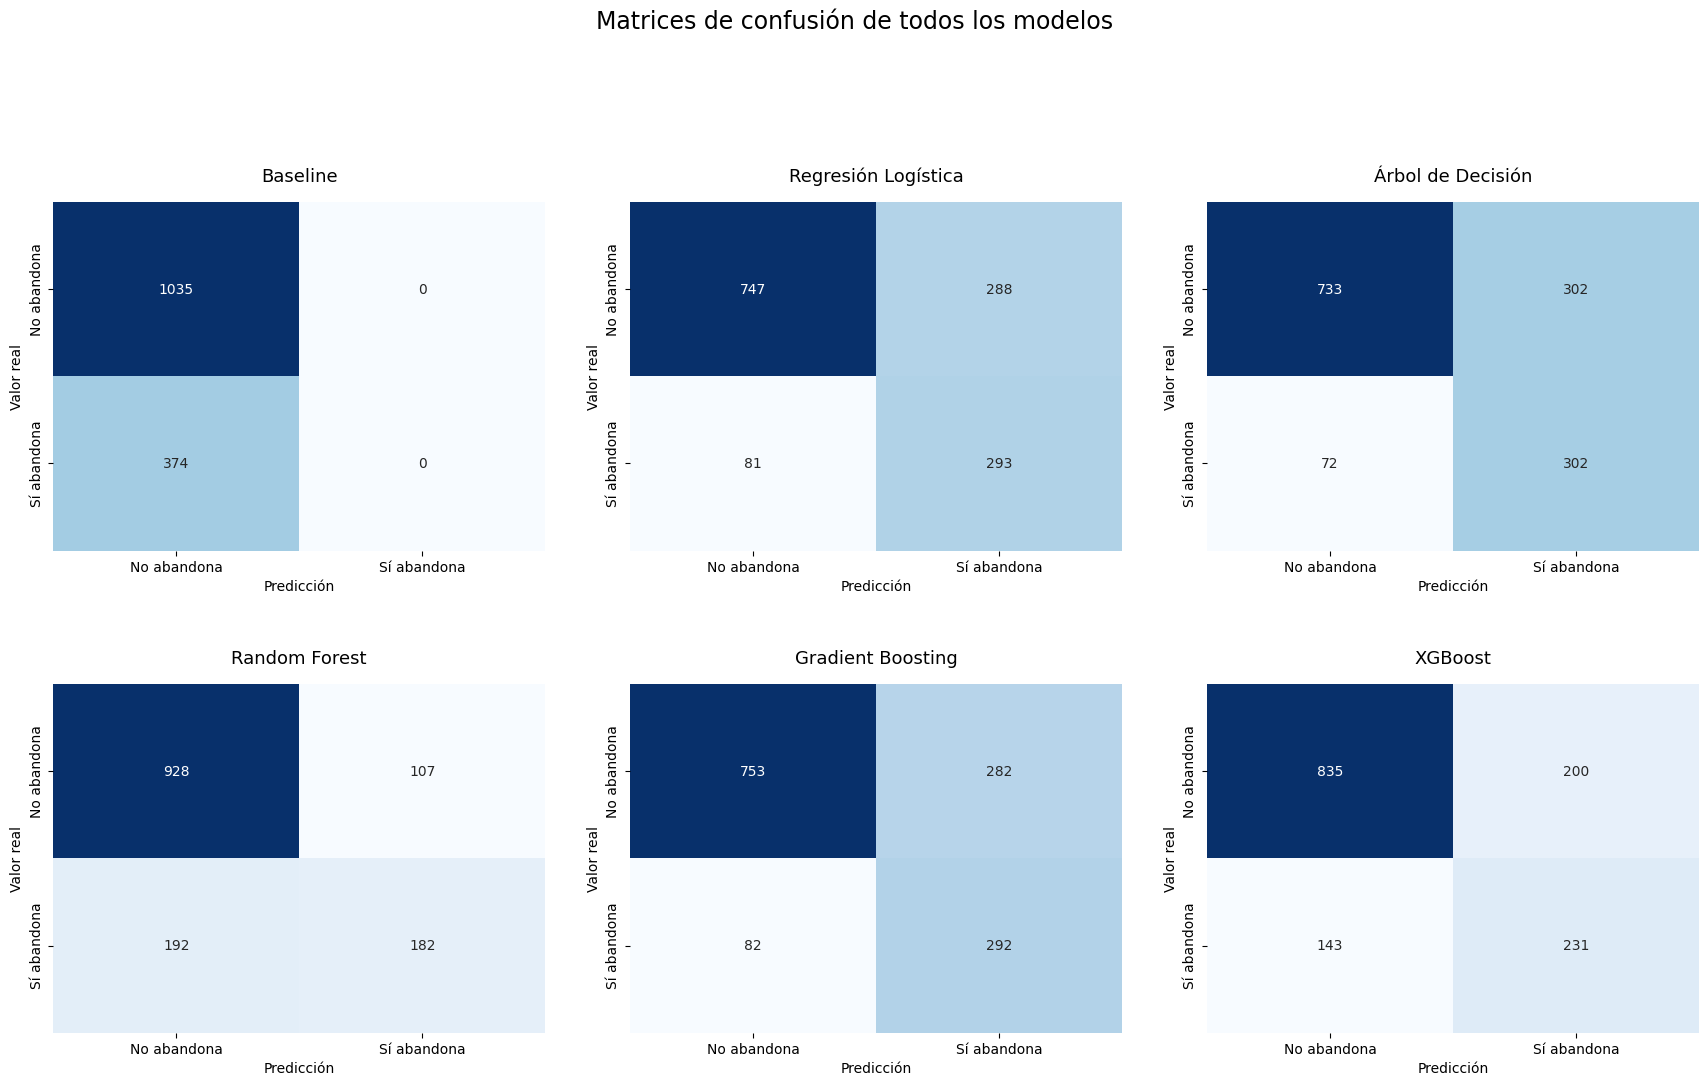

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

modelos_matrices = {
    'Baseline': y_pred_baseline,
    'Regresión Logística': y_pred_log,
    'Árbol de Decisión': y_pred_arbol,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'XGBoost': y_pred_xgb,
}

for i, (nombre, y_pred) in enumerate(modelos_matrices.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No abandona', 'Sí abandona'],
                yticklabels=['No abandona', 'Sí abandona'],
                ax=axes[i])
    axes[i].set_title(nombre, fontsize=13, pad=15)
    axes[i].set_xlabel('Predicción', fontsize=10)
    axes[i].set_ylabel('Valor real', fontsize=10)

fig.suptitle('Matrices de confusión de todos los modelos', fontsize=17, y=1.02)
plt.tight_layout(pad=4, w_pad=3, h_pad=4)
plt.savefig(f'{ruta_imagenes}imagen_11_matrices_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

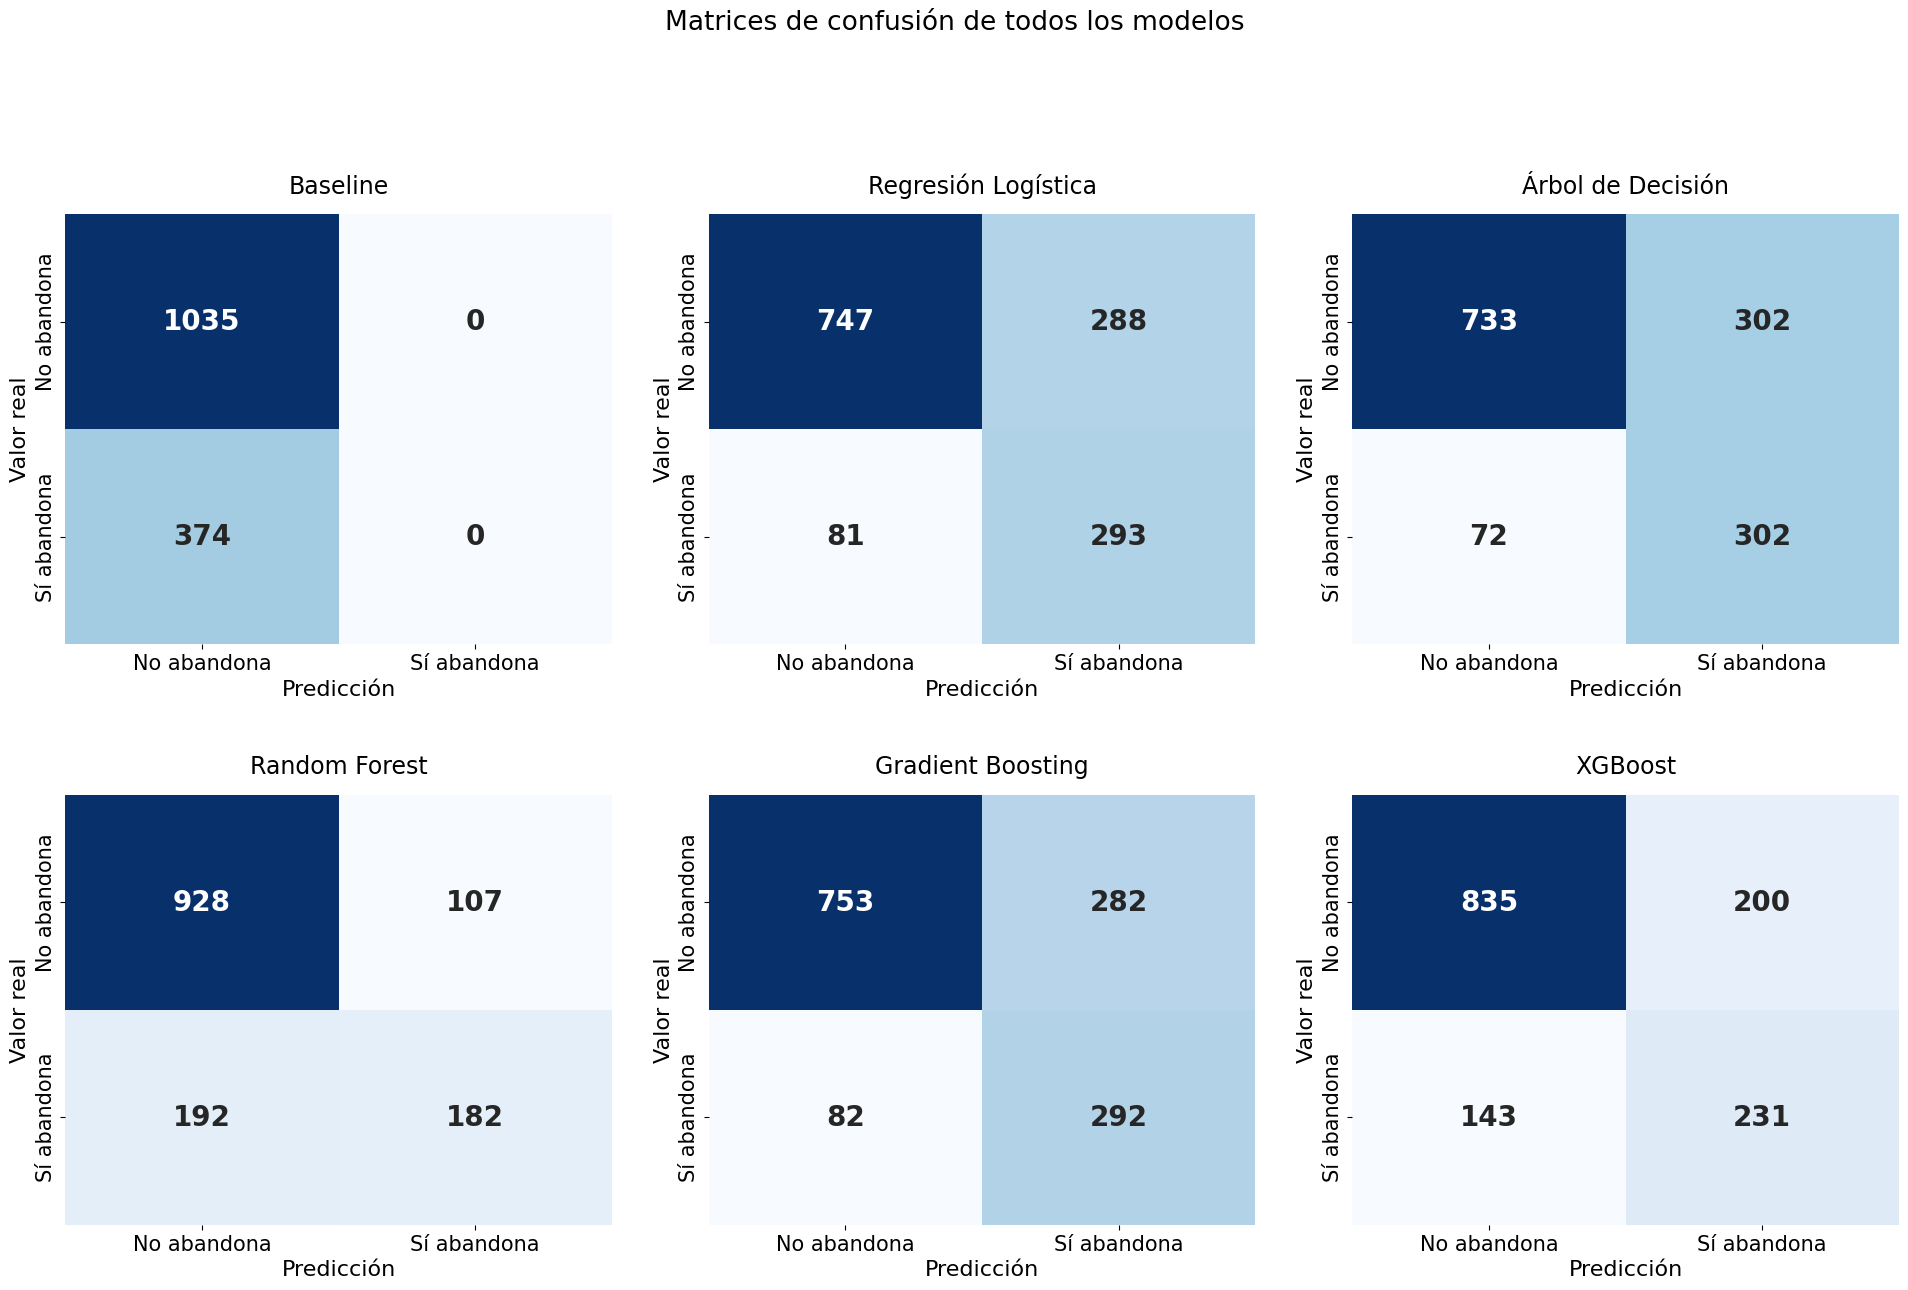

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

modelos_matrices = {
    'Baseline': y_pred_baseline,
    'Regresión Logística': y_pred_log,
    'Árbol de Decisión': y_pred_arbol,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'XGBoost': y_pred_xgb,
}

for i, (nombre, y_pred) in enumerate(modelos_matrices.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No abandona', 'Sí abandona'],
                yticklabels=['No abandona', 'Sí abandona'],
                annot_kws={'size': 20, 'weight': 'bold'},
                ax=axes[i])
    axes[i].set_title(nombre, fontsize=17, pad=15)
    axes[i].set_xlabel('Predicción', fontsize=16)
    axes[i].set_ylabel('Valor real', fontsize=16)
    axes[i].tick_params(axis='both', labelsize=15)

fig.suptitle('Matrices de confusión de todos los modelos', fontsize=19, y=1.02)
plt.tight_layout(pad=4, w_pad=3, h_pad=4)
plt.savefig(f'{ruta_imagenes}imagen_11a_matrices_confusion.png', dpi=350, bbox_inches='tight')
plt.show()

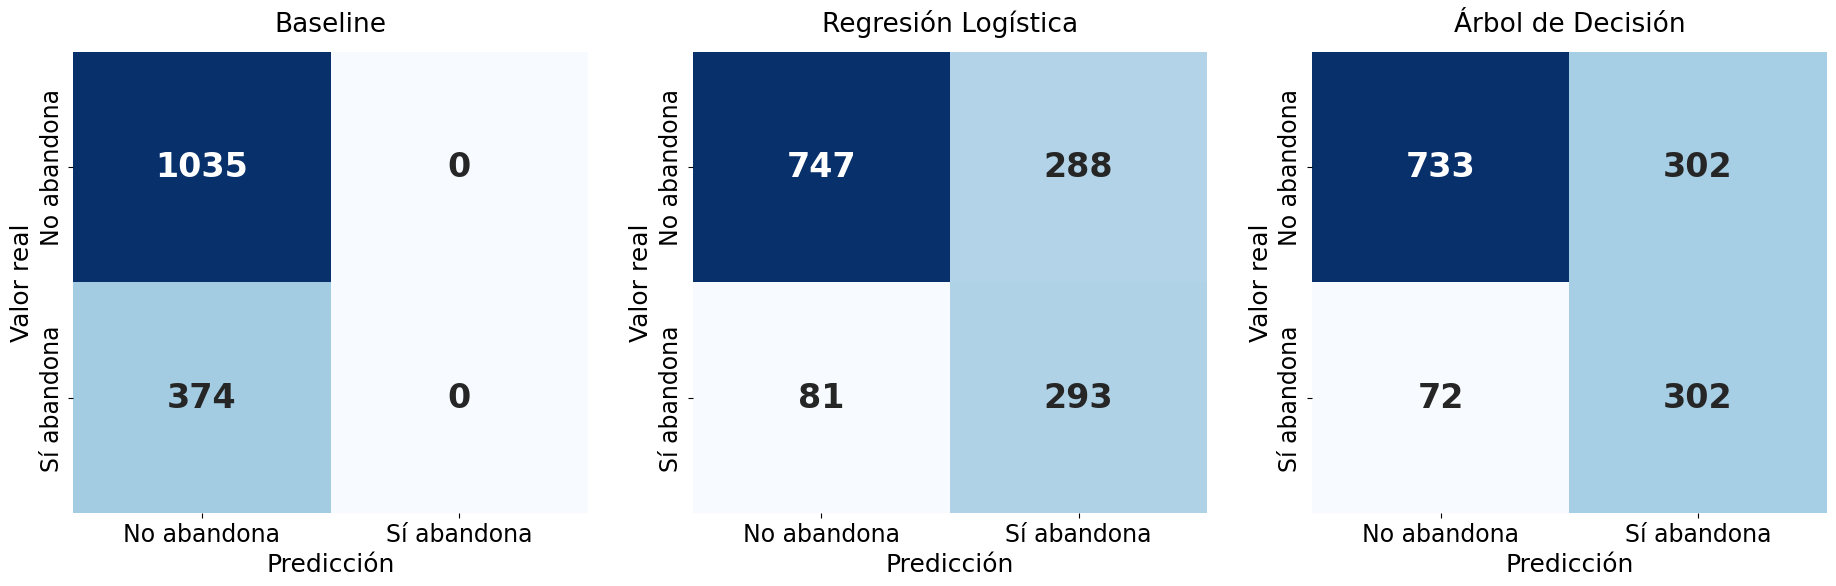

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))

modelos_grupo1 = {
    'Baseline': y_pred_baseline,
    'Regresión Logística': y_pred_log,
    'Árbol de Decisión': y_pred_arbol,
}

for i, (nombre, y_pred) in enumerate(modelos_grupo1.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No abandona', 'Sí abandona'],
                yticklabels=['No abandona', 'Sí abandona'],
                annot_kws={'size': 24, 'weight': 'bold'},
                ax=axes[i])
    axes[i].set_title(nombre, fontsize=19, pad=15)
    axes[i].set_xlabel('Predicción', fontsize=18)
    axes[i].set_ylabel('Valor real', fontsize=18)
    axes[i].tick_params(axis='both', labelsize=17)

plt.tight_layout(pad=3, w_pad=3)
# Esto la guarda en tu carpeta de Drive, junto a las demás imágenes del EDA:
plt.savefig(f'{ruta_imagenes}imagen_11b_matrices_confusion.png', dpi=350, bbox_inches='tight')
plt.show()

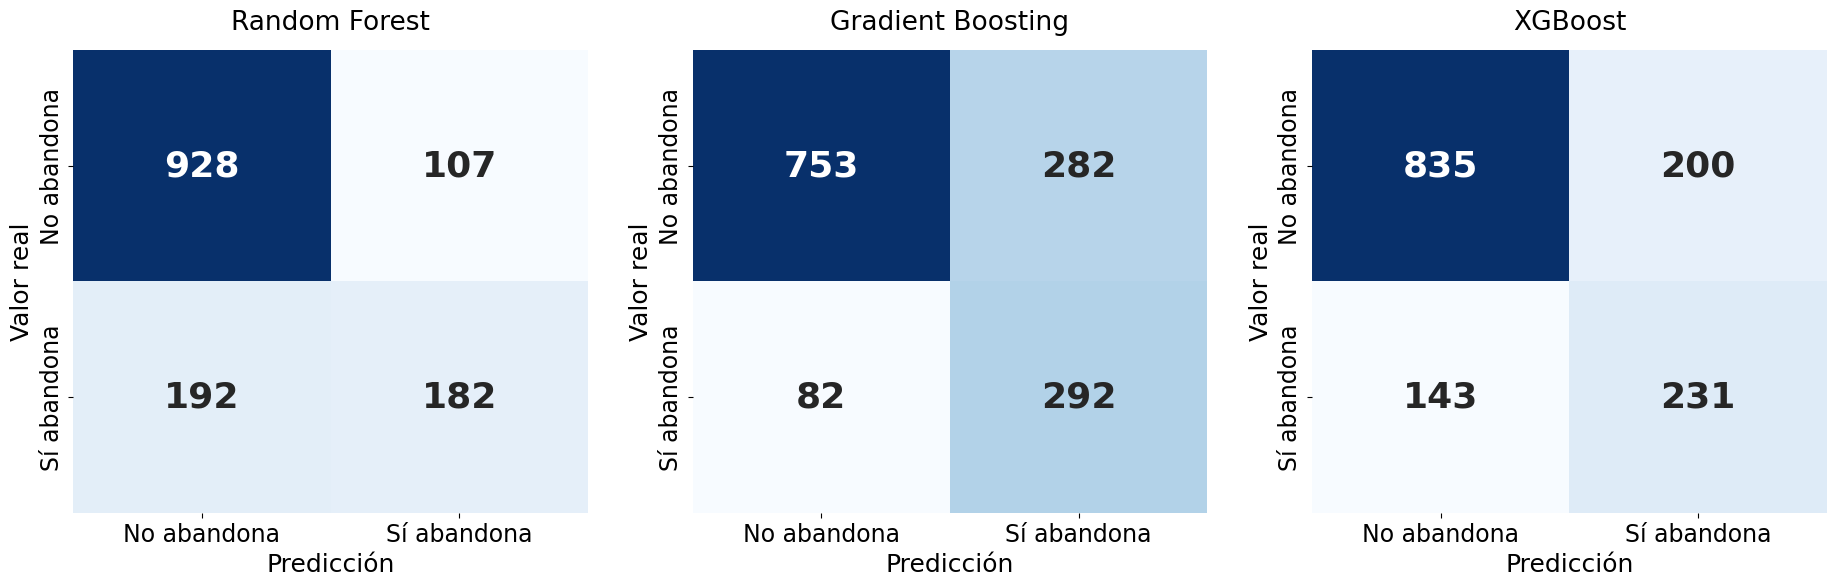

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))

modelos_grupo2 = {
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'XGBoost': y_pred_xgb,
}

for i, (nombre, y_pred) in enumerate(modelos_grupo2.items()):
    matriz = confusion_matrix(y_test, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No abandona', 'Sí abandona'],
                yticklabels=['No abandona', 'Sí abandona'],
                annot_kws={'size': 26, 'weight': 'bold'},
                ax=axes[i])
    axes[i].set_title(nombre, fontsize=19, pad=15)
    axes[i].set_xlabel('Predicción', fontsize=18)
    axes[i].set_ylabel('Valor real', fontsize=18)
    axes[i].tick_params(axis='both', labelsize=17)

plt.tight_layout(pad=3, w_pad=3)
plt.savefig(f'{ruta_imagenes}imagen_11c_matrices_confusion.png', dpi=350, bbox_inches='tight')
plt.show()

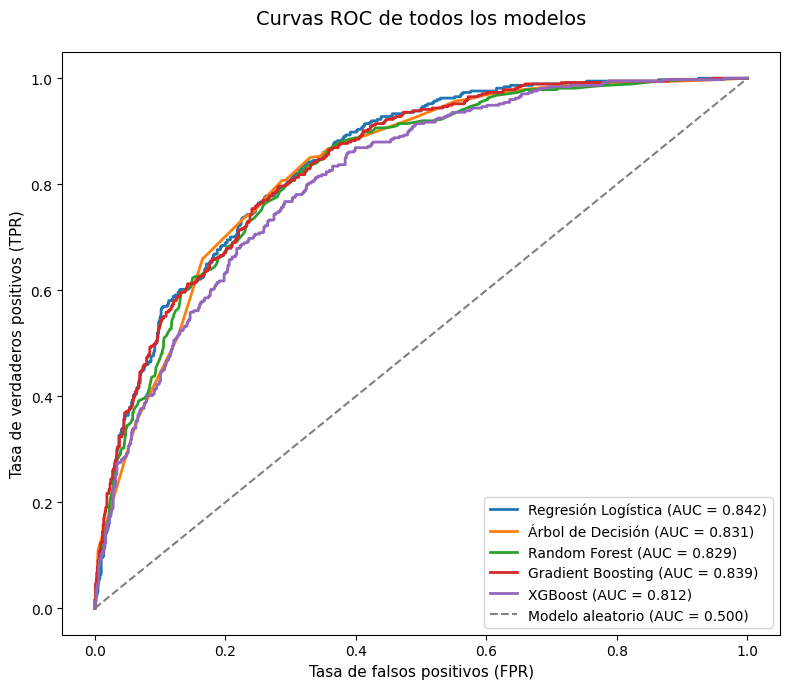

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

# Excluimos el baseline: al predecir siempre la misma clase, su probabilidad
# es constante para todos los clientes, y su curva ROC no aporta información real
modelos_roc = {
    'Regresión Logística': y_proba_log,
    'Árbol de Decisión': y_proba_arbol,
    'Random Forest': y_proba_rf,
    'Gradient Boosting': y_proba_gb,
    'XGBoost': y_proba_xgb,
}

for nombre, y_proba in modelos_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', linewidth=2)

# Línea de referencia de un modelo aleatorio (AUC = 0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio (AUC = 0.500)')

plt.title('Curvas ROC de todos los modelos', fontsize=14, pad=20)
plt.xlabel('Tasa de falsos positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de verdaderos positivos (TPR)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_12_curvas_roc.png', dpi=300, bbox_inches='tight')
plt.show()

Interpretación conjunta

La tabla comparativa confirma con números exactos todo lo que veníamos discutiendo modelo por modelo, ahora ordenados de forma consistente. Se ve muy claro que Regresión Logística, Árbol de Decisión y Gradient Boosting forman un grupo con recalls altos (0.78-0.81) y AUC-ROC por encima de 0.83, mientras que Random Forest y XGBoost forman otro grupo con recalls más bajos (0.49 y 0.62) pero mejor precisión y accuracy.

Las matrices de confusión permiten visualizar exactamente lo mismo de un vistazo: fíjate en el patrón de la fila inferior de cada matriz (los clientes que realmente abandonan). En Regresión Logística, Árbol de Decisión y Gradient Boosting, esa fila está mucho más "repartida hacia la derecha" (293, 302 y 292 detectados correctamente), mientras que en Random Forest y XGBoost hay bastantes más casos en la izquierda, es decir, clientes que abandonan pero el modelo predijo que no lo harían (192 y 143 falsos negativos). Es una forma muy visual de mostrarle al lector de tu memoria el mismo hallazgo que ya veníamos comentando con números.
Las curvas ROC, por su parte, muestran algo interesante: las cinco líneas están bastante juntas entre sí durante buena parte del gráfico, especialmente en la zona de tasas de falsos positivos bajas, y solo se empiezan a separar un poco más hacia la mitad de la curva, donde XGBoost (línea morada) se queda ligeramente por debajo del resto. Esto refuerza la idea de que, en términos de capacidad de discriminación pura (independiente del umbral de decisión), los cinco modelos son bastante parecidos, y las diferencias más marcadas que vimos en precisión y recall tienen más que ver con el umbral de 0.5 que cada modelo usa por defecto para decidir, que con una diferencia real en la calidad del modelo subyacente.

**memoria**

Con el fin de sintetizar visualmente los resultados obtenidos, se elaboró una tabla comparativa con las principales métricas de evaluación de los seis modelos entrenados (baseline, Regresión Logística, Árbol de Decisión, Random Forest, Gradient Boosting y XGBoost), junto con las matrices de confusión y las curvas ROC de cada uno de ellos. Las matrices de confusión permitieron observar con claridad las diferencias en la capacidad de detección de los clientes que efectivamente abandonan (374 casos en el conjunto de prueba): la Regresión Logística, el Árbol de Decisión y Gradient Boosting identificaron correctamente a 293, 302 y 292 de estos clientes respectivamente, dejando sin detectar entre 72 y 82 casos, mientras que Random Forest y XGBoost solo lograron identificar a 182 y 231 clientes respectivamente, dejando sin detectar a 192 y 143 casos.

Esta comparación permitió identificar dos grupos de modelos: por un lado, la Regresión Logística, el Árbol de Decisión y Gradient Boosting, con un recall elevado (entre el 78% y el 81%) para la clase de clientes que abandonan y un área bajo la curva ROC superior a 0,83; y por otro, Random Forest y XGBoost, con una menor sensibilidad hacia dicha clase, aunque con una mayor precisión y exactitud global.

En términos de capacidad de discriminación global, medida mediante el área bajo la curva ROC, la Regresión Logística obtuvo el mejor resultado (0,842), seguida muy de cerca por Gradient Boosting (0,839), el Árbol de Decisión (0,831) y Random Forest (0,829), mientras que XGBoost presentó el rendimiento más discreto del conjunto (0,812).

Dado que las diferencias entre los cuatro primeros modelos resultaron reducidas, la elección del modelo final se orientó hacia aquel que ofreciera el mejor equilibrio entre capacidad predictiva e interpretabilidad, aspecto especialmente relevante dado el enfoque explicable del presente trabajo.

Al evaluar el rendimiento global, tanto la Regresión Logística (AUC: 0.842, Recall: 78.3%) como Gradient Boosting (AUC: 0.839, Recall: 78.1%) presentaron los mejores resultados del estudio, con un comportamiento prácticamente idéntico en la detección de clientes en riesgo de abandono. Sin embargo, para la fase de despliegue y análisis interpretativo se selecciona Gradient Boosting como el modelo candidato principal.

Al tratarse de un algoritmo no lineal de ensamblado (caja negra), permite capturar interacciones complejas entre las variables que los modelos lineales no pueden reflejar. La posterior aplicación de SHAP y LIME sobre este modelo resuelve el reto de la interpretabilidad, proporcionando al área de negocio perfiles de riesgo detallados y explicaciones locales precisas para el diseño de campañas de fidelización."


-------------------------------
A la luz de los resultados obtenidos, tanto la Regresión Logística (AUC: 0.842, Recall: 78.3%) como Gradient Boosting (AUC: 0.839, Recall: 78.1%) destacan como los modelos de mejor rendimiento para la detección de abandono.

Se selecciona Gradient Boosting como el modelo final para la fase de producción y explicabilidad. Al ser un algoritmo de ensamblado no lineal (caja negra), posee una mayor capacidad para capturar patrones interactivos complejos entre las variables de los clientes. Para superar la falta de transparencia inherente a este tipo de modelos, se aplican las técnicas SHAP y LIME, permitiendo extraer los factores clave de fuga a nivel global y local para el diseño de las estrategias de fidelización del área de negocio.

**Párrafo de transición para la memoria**

Este iría justo después del párrafo de cierre de la comparación de modelos (el de "Con el fin de sintetizar visualmente los resultados obtenidos..."):

Considerando el conjunto de resultados obtenidos, se seleccionó Gradient Boosting como modelo final del presente trabajo. Esta decisión se fundamentó en su elevada capacidad de detección de clientes en riesgo de abandono (recall del 78%), muy similar a la del mejor modelo en términos de área bajo la curva ROC (Regresión Logística), así como en su buen desempeño global (exactitud del 74% y AUC-ROC de 0,839, el segundo más alto de toda la comparación). Adicionalmente, al tratarse de un modelo basado en árboles de decisión, Gradient Boosting resulta especialmente adecuado para la aplicación de técnicas de explicabilidad basadas en SHAP, las cuales permiten interpretar de forma detallada tanto el comportamiento global del modelo como sus predicciones individuales, en línea con el objetivo explicable planteado para el presente TFM.

Fase de explicabilidad con SHAP

La idea de SHAP es sencilla de entender aunque su matemática interna sea compleja: para cada cliente y cada variable, SHAP calcula un "valor de contribución" que te dice cuánto empujó esa variable la predicción hacia "sí abandona" o hacia "no abandona", comparado con la predicción promedio del modelo. Si sumas todas esas contribuciones de un cliente, obtienes exactamente la predicción final que dio el modelo para ese cliente. Esto nos va a permitir responder tanto preguntas globales ("¿qué variables usa más el modelo en general?") como preguntas individuales ("¿por qué el modelo predijo que este cliente en concreto va a abandonar?").

In [ ]:
# ============================
# EXPLICABILIDAD - SHAP
# ============================

!pip install shap -q

import shap

# TreeExplainer está optimizado para modelos basados en árboles, como Gradient Boosting
explainer = shap.TreeExplainer(modelo_gb)

# Calculamos los valores SHAP para el conjunto de test
shap_values = explainer.shap_values(X_test)

print("Forma de shap_values:", shap_values.shape)
print("Forma de X_test:", X_test.shape)

Forma de shap_values: (1409, 30)
Forma de X_test: (1409, 30)


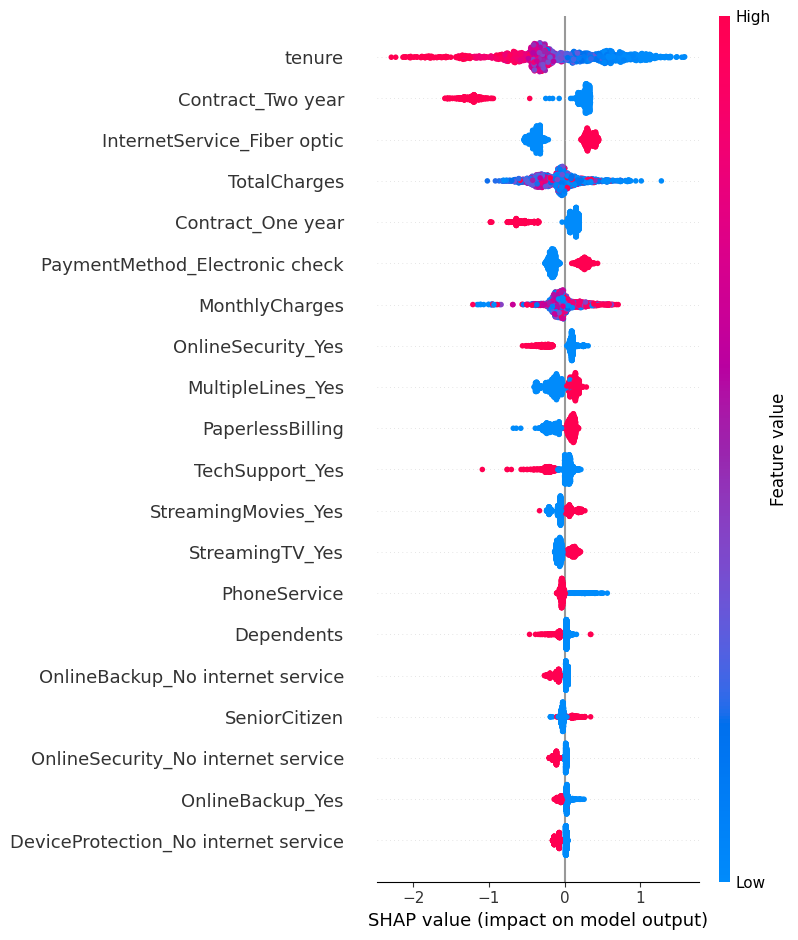

In [ ]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig(f'{ruta_imagenes}imagen_16_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

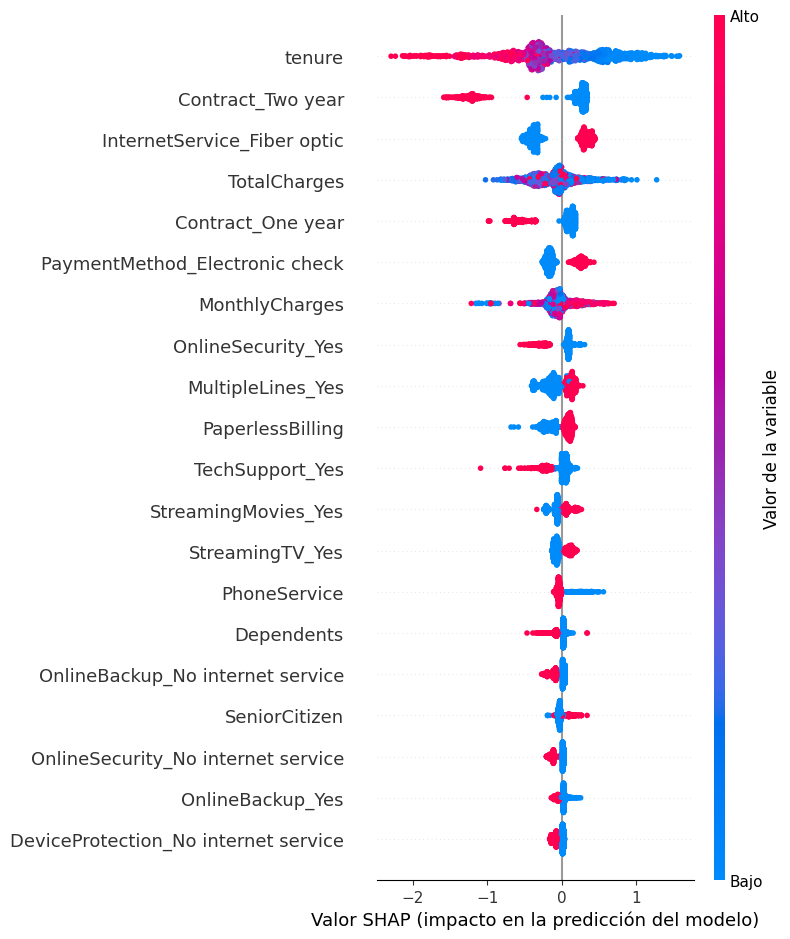

In [ ]:
shap.summary_plot(shap_values, X_test, show=False)

fig = plt.gcf()
ax_principal = fig.axes[0]      # eje con las variables y los puntos SHAP
cbar_ax = fig.axes[-1]          # barra de color lateral (Feature value)

# Eje X principal, en español
ax_principal.set_xlabel('Valor SHAP (impacto en la predicción del modelo)', fontsize=13)

# Barra de color lateral: título y extremos "High"/"Low" en español
cbar_ax.set_ylabel('Valor de la variable', fontsize=12)
cbar_ax.set_yticklabels(['Bajo', 'Alto'], fontsize=11)

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_16b_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()


Interpretación

Empezando por arriba (las variables más importantes para el modelo): tenure es, por lejos, la variable con mayor impacto, tal como ya sospechábamos desde el EDA. Fíjate en el patrón de colores: los puntos azules (antigüedad baja) se extienden hacia la derecha (SHAP positivo, empuja hacia "abandona"), mientras que los puntos rojos/morados (antigüedad alta) se concentran hacia la izquierda (empuja hacia "no abandona"). Es exactamente la misma historia que contamos en el EDA, solo que ahora el modelo lo confirma de forma cuantitativa y a nivel de cada cliente individual.

Contract_Two year es la segunda variable más importante: los puntos rojos (clientes que sí tienen contrato de dos años, valor = 1) están muy concentrados hacia la izquierda, es decir, tener este tipo de contrato reduce fuertemente la probabilidad de abandono, mientras que los puntos azules (no tienen este contrato) se reparten más hacia la derecha. De nuevo, coincide con lo que ya habíamos visto: el contrato largo es una barrera de salida potente.

InternetService_Fiber optic, TotalCharges, Contract_One year, PaymentMethod_Electronic check y MonthlyCharges completan el grupo de variables más influyentes, y todas mantienen la misma dirección que veníamos observando desde el análisis exploratorio: fibra óptica, cargos mensuales altos y pago con cheque electrónico empujan hacia el abandono (puntos rojos a la derecha), mientras que cargos totales altos (que reflejan mayor antigüedad) y contrato anual empujan hacia la permanencia.

Más abajo en el gráfico aparecen variables con impacto mucho más discreto, como OnlineSecurity_Yes, TechSupport_Yes, PaperlessBilling, o ya casi sin efecto visible, como SeniorCitizen, Dependents y varias relacionadas con "No internet service". Esto también es coherente con lo que ya habíamos notado: esas variables aportan relativamente poca señal al modelo.


Este es un hallazgo importante para destacar en tu memoria: el modelo Gradient Boosting, sin que le dijéramos nada explícitamente, terminó aprendiendo y priorizando exactamente las mismas variables y en las mismas direcciones que ya habíamos identificado "a mano" en el análisis exploratorio. Esto refuerza la confianza en que el modelo está capturando relaciones reales del negocio, y no patrones espurios o ruido.




**MEMORIA**

Con el fin de analizar el comportamiento global del modelo seleccionado, se generó un summary plot mediante la librería SHAP, que permite visualizar simultáneamente la importancia de cada variable, la dirección de su efecto sobre la predicción y su relación con el valor observado en cada cliente. El análisis reveló que la variable con mayor influencia sobre la predicción de abandono es tenure, donde los valores bajos de antigüedad se asocian de forma consistente con un mayor riesgo de abandono, mientras que los valores altos empujan la predicción hacia la permanencia del cliente. En segundo lugar, la variable Contract_Two year mostró un efecto marcadamente protector frente al abandono, en línea con los hallazgos obtenidos previamente en el análisis exploratorio de datos.

Asimismo, variables como InternetService_Fiber optic, PaymentMethod_Electronic check y MonthlyCharges se asociaron con un mayor riesgo de abandono cuando presentaban valores elevados, mientras que TotalCharges y Contract_One year mostraron un efecto protector. En conjunto, estos resultados evidencian una notable coherencia entre las variables identificadas como más relevantes por el modelo y aquellas que ya habían sido señaladas como determinantes durante el análisis exploratorio de datos, lo que refuerza la validez del modelo entrenado y su capacidad para capturar relaciones significativas del negocio, más allá de patrones espurios en los datos.



¡Perfecto! Vamos con el gráfico de barras primero. Este gráfico es un complemento del summary_plot que ya interpretamos: mientras que el anterior mostraba la dispersión de valores SHAP (con colores para valores altos/bajos), este resume cada variable en un solo número: el promedio del valor absoluto de SHAP. Es decir, responde a la pregunta "¿qué tan importante es esta variable en promedio, sin importar si empuja hacia churn o hacia no-churn?".

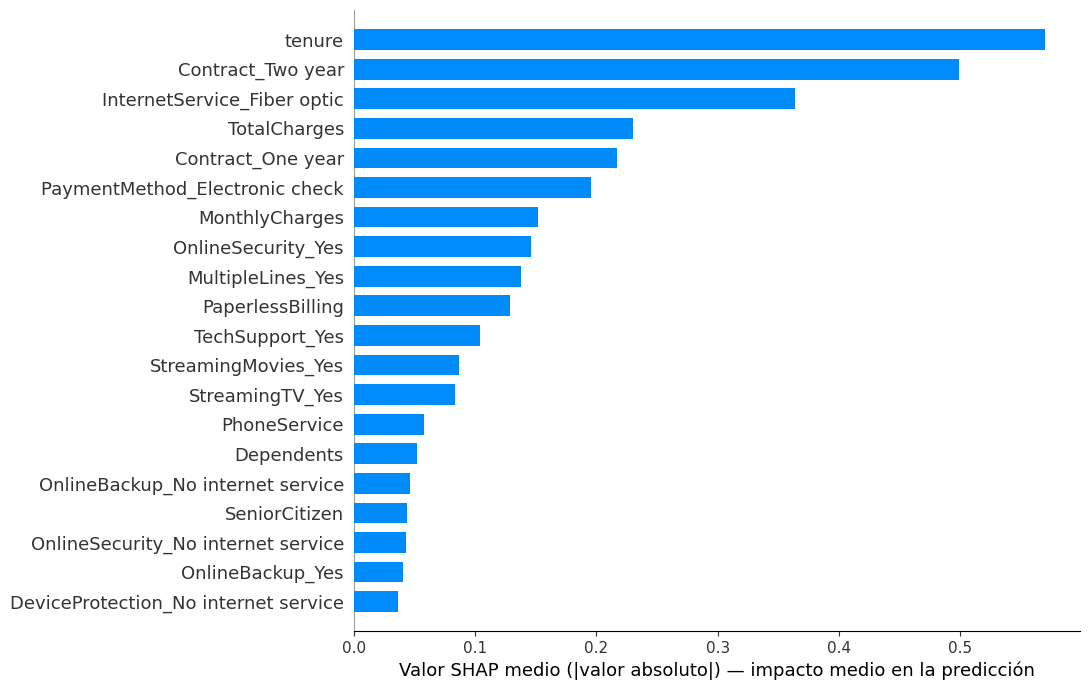

In [ ]:
# Gráfico de importancia global SHAP en barras (valor absoluto medio)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, plot_size=(11, 7))

# Sobrescribimos la etiqueta del eje X: mismo significado, pero más corta y con
# el tamaño de letra bajo control para que quepa completa
plt.xlabel('Valor SHAP medio (|valor absoluto|) — impacto medio en la predicción', fontsize=13)

plt.tight_layout()
plt.savefig(f'{ruta_imagenes}imagen_17_shap_bar_plot.png', bbox_inches='tight', dpi=300)
plt.show()

**MEMORIA**

El gráfico de importancia global en barras resume el aporte medio de cada variable al modelo, calculado como el promedio del valor absoluto de sus valores SHAP, sin distinguir la dirección del efecto. Este análisis confirma la jerarquía de variables observada en el gráfico de dispersión anterior: la antigüedad del cliente, el tipo de contrato (especialmente el contrato de dos años) y el uso de fibra óptica se mantienen como los factores con mayor influencia en las predicciones del modelo. Le siguen el importe total facturado, el contrato de un año, el método de pago mediante cheque electrónico y el importe mensual facturado.

El resto de variables, relacionadas con servicios adicionales como seguridad online, soporte técnico o streaming, presentan un impacto considerablemente menor, mientras que variables demográficas como tener dependientes o ser persona mayor se sitúan entre las de menor relevancia para el modelo. Esta vista complementa a la anterior al ofrecer una jerarquía clara y sencilla de interpretar, útil para comunicar de forma directa qué variables debería priorizar el negocio a la hora de diseñar estrategias de retención.

Ahora pasemos a las explicaciones locales. La idea aquí es dejar de ver el modelo "en general" y mirar clientes concretos: por qué el modelo predijo que un cliente específico se va a ir (o que se va a quedar), variable por variable. Para esto usamos el waterfall plot, que es el más claro visualmente y el que recomienda la documentación actual de SHAP (el force plot es una versión más antigua con la misma idea).
Antes de darte el código, te propongo elegir dos casos representativos e interesantes para la memoria:
Un cliente que el modelo predice correctamente como "se va" (verdadero positivo), para mostrar qué variables llevaron a esa decisión. Y un cliente que el modelo predice correctamente como "se queda" (verdadero negativo), para mostrar el contraste. Si quieres, después también podemos ver un caso donde el modelo se equivoca (falso positivo o falso negativo), que suele ser muy interesante para la memoria porque muestra los límites del modelo.

In [ ]:
# Identificamos clientes de ejemplo según el resultado de la predicción
y_pred_gb = modelo_gb.predict(X_test)
y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

# Verdadero positivo: el cliente se fue Y el modelo lo predijo correctamente
idx_vp = X_test_reset[(y_test_reset == 1) & (y_pred_gb == 1)].index[0]

# Verdadero negativo: el cliente se quedó Y el modelo lo predijo correctamente
idx_vn = X_test_reset[(y_test_reset == 0) & (y_pred_gb == 0)].index[0]

print("Índice verdadero positivo:", idx_vp)
print("Índice verdadero negativo:", idx_vn)

Índice verdadero positivo: 9
Índice verdadero negativo: 0


Perfecto, ya tenemos nuestros dos clientes: índice 9 (verdadero positivo, el cliente se fue y el modelo lo predijo bien) e índice 0 (verdadero negativo, el cliente se quedó y el modelo lo predijo bien).

El waterfall plot funciona así: parte de un valor base (lo que el modelo predeciría "en promedio", sin conocer nada del cliente) y luego suma o resta el efecto de cada variable, una por una, hasta llegar a la predicción final para ese cliente concreto. Las barras rojas empujan hacia churn, las azules empujan hacia no-churn.

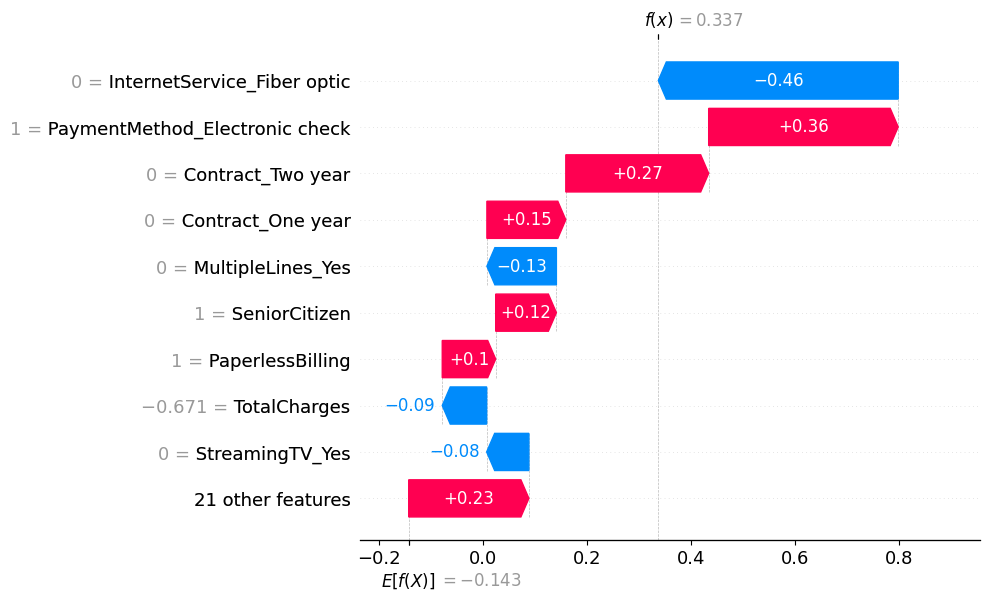

In [ ]:
# Waterfall plot para el cliente verdadero positivo (índice 9)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_vp],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[idx_vp],
    feature_names=X_test_reset.columns.tolist()
), show=False)

plt.savefig(f'{ruta_imagenes}imagen_18_shap_waterfall_vp.png',
            bbox_inches='tight', dpi=300)
plt.show()

El valor base E[f(X)] = -0.143 es lo que el modelo predice "de partida", antes de mirar a este cliente en particular. La predicción final para este cliente es f(x) = 0.337, un valor bastante más alto, lo que confirma que el modelo lo clasificó como propenso a irse. Nota: este valor no es directamente una probabilidad (es la salida en escala logarítmica del modelo, antes de convertirla a probabilidad), pero cuanto más alto, más empuja hacia churn.

Mirando las variables que más influyeron en subir esa predicción: el que este cliente pague mediante cheque electrónico (PaymentMethod_Electronic check = 1) suma +0.36, y el hecho de no tener contrato de dos años (Contract_Two year = 0) suma +0.27, seguido de no tener contrato de un año (+0.15) y ser persona mayor (+0.12).

En conjunto, esto pinta el perfil típico de cliente en riesgo: sin compromiso contractual a largo plazo y con un método de pago menos automatizado. Por otro lado, el no tener fibra óptica (InternetService_Fiber optic = 0) resta -0.46, siendo la variable que más empujó en sentido contrario (hacia no-churn), aunque no fue suficiente para contrarrestar el resto de factores en contra.

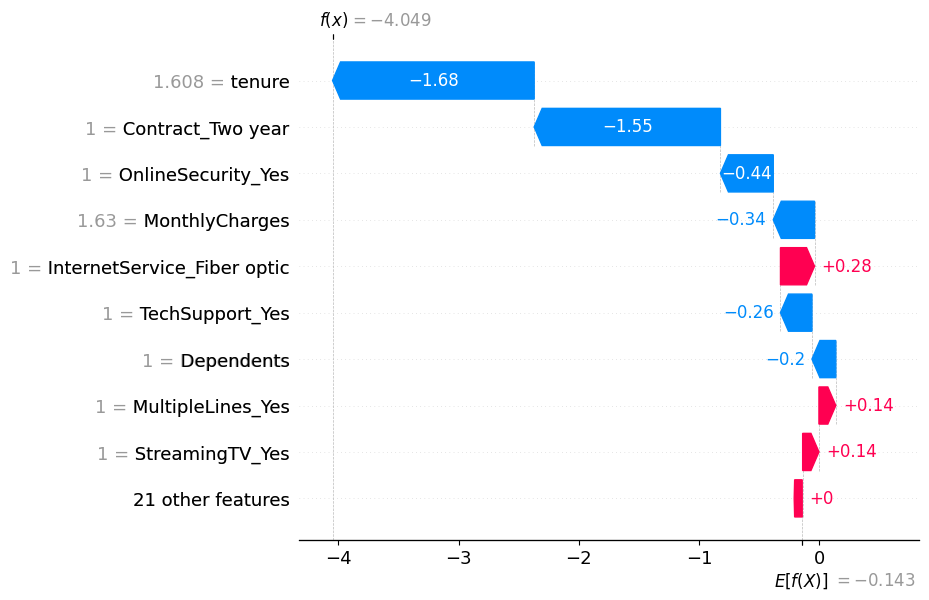

In [ ]:
# Waterfall plot para el cliente verdadero negativo (índice 0)
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_vn],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[idx_vn],
    feature_names=X_test_reset.columns.tolist()
), show=False)

plt.savefig(f'{ruta_imagenes}imagen_19_shap_waterfall_vn.png',
            bbox_inches='tight', dpi=300)
plt.show()

Excelente, este segundo caso es un contraste muy claro con el anterior. Aquí el valor base sigue siendo el mismo E[f(X)] = -0.143, pero la predicción final cae hasta f(x) = -4.049, un valor mucho más bajo, coherente con un cliente que el modelo considera muy poco propenso a irse.

Lo interesante es que las dos variables que más empujan hacia no-churn son justo las que en el caso anterior jugaban en contra: tener una antigüedad alta (tenure = 1.608, en su valor escalado, es decir, muy por encima del promedio) resta -1.68, y tener contrato de dos años (Contract_Two year = 1) resta -1.55. Entre las dos, casi explican por sí solas la caída de la predicción. Además se suman otros factores en la misma dirección aunque de menor peso: tener seguridad online, un cargo mensual alto, soporte técnico y tener dependientes, todo esto también empuja levemente hacia no-churn. Solo unas pocas variables empujan tímidamente en dirección contraria, como tener fibra óptica (+0.28) o tener streaming de TV (+0.14), pero su efecto es pequeño comparado con el peso de la antigüedad y el contrato.

El análisis de explicaciones locales mediante gráficos de cascada (waterfall plots) permite observar cómo el modelo construye su predicción para clientes individuales a partir de un valor base común, sumando o restando el efecto de cada variable. En el caso de un cliente correctamente identificado como propenso al abandono, el modelo eleva su predicción principalmente por no contar con un contrato de larga duración, por utilizar cheque electrónico como método de pago y por tratarse de una persona mayor, factores que en conjunto reflejan un perfil de menor compromiso con la compañía.

En cambio, en el caso de un cliente correctamente identificado como fiel, la predicción desciende de forma muy marcada debido principalmente a su elevada antigüedad y a contar con un contrato de dos años, dos variables que por sí solas explican la mayor parte de la baja probabilidad de abandono estimada. Esta comparación evidencia que, más allá de la importancia global de las variables, su efecto concreto depende del perfil de cada cliente, y refuerza el papel de la antigüedad y el tipo de contrato como los elementos más determinantes en las decisiones del modelo.

In [ ]:
# Identificamos un cliente falso positivo: el modelo predijo churn, pero el cliente se quedó
idx_fp = X_test_reset[(y_test_reset == 0) & (y_pred_gb == 1)].index[0]
print("Índice falso positivo:", idx_fp)

Índice falso positivo: 1


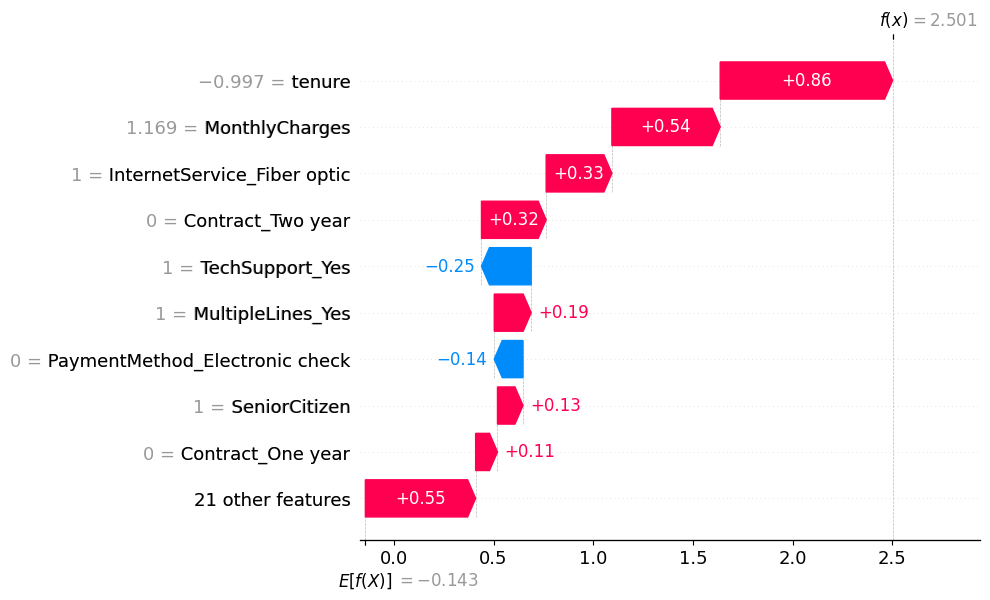

In [ ]:
# Waterfall plot para el cliente falso positivo
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_fp],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[idx_fp],
    feature_names=X_test_reset.columns.tolist()
), show=False)

plt.savefig(f'{ruta_imagenes}imagen_20_shap_waterfall_fp.png',
            bbox_inches='tight', dpi=300)
plt.show()

Para complementar el análisis de casos correctamente clasificados, se examinó también un ejemplo de error del modelo: un cliente falso positivo, es decir, predicho como propenso al abandono cuando en realidad permaneció en la compañía. En este caso, el modelo asignó un valor de predicción incluso superior al observado en el cliente verdadero positivo analizado previamente, impulsado principalmente por una antigüedad muy baja, un cargo mensual elevado, el uso de fibra óptica y la ausencia de un contrato de larga duración.

Este ejemplo pone de manifiesto que, aunque el modelo identifica correctamente un perfil de riesgo coherente con los patrones generales aprendidos, no todos los clientes con estas características terminan abandonando el servicio, lo que sugiere la posible influencia de factores no recogidos en los datos disponibles, como el nivel de satisfacción o la relación particular de cada cliente con la empresa.

Este tipo de casos resulta especialmente valioso para la interpretación del modelo, ya que evidencia sus límites y refuerza la idea de que sus predicciones deben entenderse como una herramienta de apoyo a la decisión, y no como una certeza absoluta sobre el comportamiento futuro de cada cliente.

In [ ]:
# Identificamos un cliente falso negativo: el modelo predijo que se quedaba, pero el cliente se fue
idx_fn = X_test_reset[(y_test_reset == 1) & (y_pred_gb == 0)].index[0]
print("Índice falso negativo:", idx_fn)

Índice falso negativo: 39


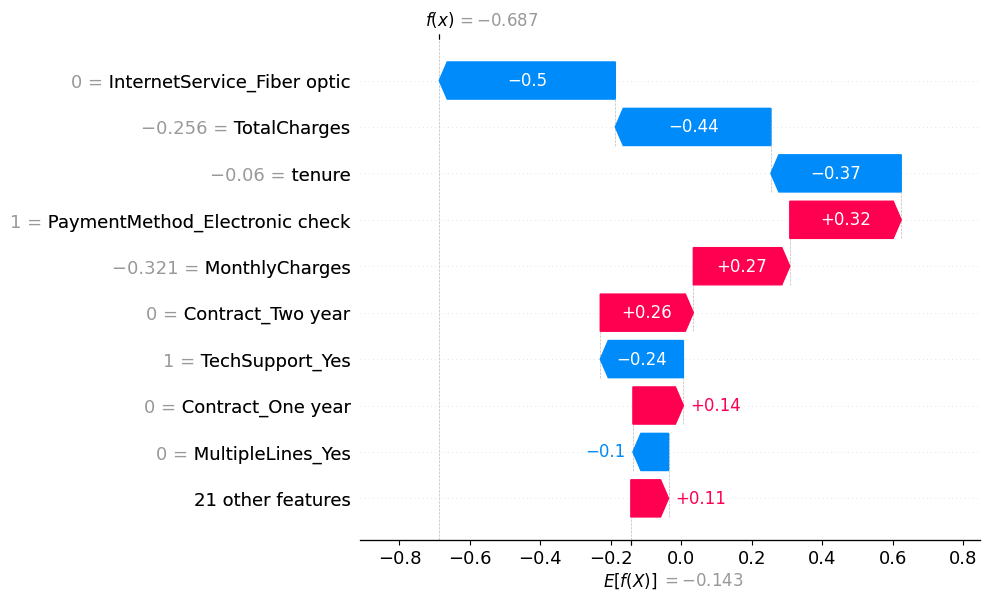

In [ ]:
# Waterfall plot para el cliente falso negativo
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_fn],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[idx_fn],
    feature_names=X_test_reset.columns.tolist()
), show=False)

plt.savefig(f'{ruta_imagenes}imagen_21_shap_waterfall_fn.png',
            bbox_inches='tight', dpi=300)
plt.show()

Este es el caso más costoso para el negocio, así que vale la pena mirarlo con cuidado. Aquí f(x) = -0.687, un valor por debajo del valor base (-0.143), lo que llevó al modelo a predecir que este cliente se quedaría. Sin embargo, en la realidad, este cliente sí abandonó el servicio: es un falso negativo.

¿Por qué se equivocó el modelo? Las variables que más empujaron hacia la predicción de "no churn" fueron el no tener fibra óptica (-0.5), un importe total facturado bajo (-0.44) y una antigüedad cercana al promedio (-0.37). Estas tres variables construyen, en apariencia, el perfil de un cliente "tranquilo". Sí había señales de riesgo presentes, como pagar con cheque electrónico (+0.32) y no tener contrato de dos años (+0.26), pero no fueron suficientes para superar el peso de las variables que apuntaban en sentido contrario.

Esto es justamente el reverso del caso anterior: allí el modelo sobrestimó el riesgo por un perfil de bajo compromiso contractual, y aquí lo subestimó porque el cliente no encajaba con el patrón típico de riesgo (no tenía fibra óptica ni facturaba mucho), aunque terminó marchándose igual.

**MEMORIA**

El último caso analizado corresponde a un falso negativo, es decir, un cliente que el modelo predijo como fiel pero que finalmente abandonó la compañía. Este tipo de error es el más relevante desde la perspectiva del negocio, ya que implica la pérdida de un cliente sin que se active ninguna acción preventiva. El modelo subestimó el riesgo de abandono principalmente por la ausencia de fibra óptica, un importe total facturado bajo y una antigüedad cercana al promedio, variables que en conjunto suelen asociarse a un perfil de menor riesgo. Aunque el cliente presentaba algunas señales de alerta, como el uso de cheque electrónico como método de pago y la falta de un contrato de larga duración, estas no fueron suficientes para que el modelo alterara su predicción. Este caso, junto con el falso positivo analizado previamente, pone en evidencia que los errores del modelo no son aleatorios sino que responden a los mismos patrones que sustentan sus predicciones correctas, y refuerza la necesidad de complementar el modelo con criterio humano en la toma de decisiones sobre retención de clientes.

**PROPUESTAS DE ACCIONES DE NEGOCIO**

A partir de los hallazgos obtenidos mediante el análisis de explicabilidad, es posible traducir el conocimiento generado por el modelo en propuestas concretas orientadas a reducir el abandono de clientes. Esta sección presenta un conjunto de acciones de negocio alineadas con las variables que mayor influencia demostraron tener sobre las predicciones del modelo, con el objetivo de apoyar el diseño de estrategias de fidelización más efectivas y mejor dirigidas.

Y las acciones asociadas a cada factor clave:

En primer lugar, dado que la antigüedad del cliente es la variable con mayor peso en el modelo, se recomienda diseñar programas de acompañamiento específicos para clientes nuevos, especialmente durante sus primeros meses de contrato, periodo en el que el riesgo de abandono es más alto.

En segundo lugar, considerando que los contratos de mayor duración se asocian de forma consistente con una menor probabilidad de abandono, se sugiere reforzar los incentivos comerciales para migrar a los clientes con contrato mensual hacia modalidades de uno o dos años, mediante descuentos progresivos o beneficios adicionales.

En tercer lugar, el servicio de fibra óptica aparece asociado a un mayor riesgo de abandono, posiblemente vinculado a expectativas de calidad más exigentes o a una mayor sensibilidad al precio en este segmento; se recomienda evaluar la experiencia de estos clientes de forma diferenciada, mediante encuestas de satisfacción específicas o seguimiento proactivo de incidencias técnicas.

En cuarto lugar, el uso de cheque electrónico como método de pago se relaciona con una mayor probabilidad de abandono frente a otros métodos más automatizados; se propone incentivar la migración hacia métodos de pago recurrente, como domiciliación bancaria o tarjeta, que suelen reflejar una relación más estable con la compañía.

Finalmente, dado que un importe mensual elevado también contribuye al riesgo de abandono, se recomienda revisar la propuesta de valor ofrecida a los clientes con facturación alta, mediante paquetes personalizados o beneficios adicionales que compensen la percepción de costo.

Y el párrafo de cierre:

En conjunto, estas propuestas buscan anticipar el abandono de clientes a partir de señales identificadas de forma objetiva por el modelo, permitiendo al área de negocio priorizar sus esfuerzos de retención sobre los segmentos de mayor riesgo. El uso de un modelo explicable resulta especialmente valioso en este contexto, ya que no solo permite predecir qué clientes son propensos a abandonar, sino también comprender por qué, facilitando el diseño de estrategias de fidelización más específicas y mejor fundamentadas que las basadas únicamente en la intuición o en la experiencia comercial.


Introducción

A partir del análisis de explicabilidad realizado sobre el modelo, es posible construir una lectura de negocio orientada a la acción, que responda a tres preguntas centrales: qué perfiles de cliente presentan mayor riesgo de abandono, en qué momento de su relación con la compañía resulta más oportuno intervenir, y qué tipo de acciones u ofertas resultan más adecuadas para cada caso. Esta lectura no pretende profundizar en aspectos técnicos del modelo, sino traducir sus resultados en criterios prácticos que orienten las estrategias de fidelización.

Perfiles de cliente con mayor riesgo

El modelo permite identificar con claridad los rasgos que caracterizan a los clientes más propensos a abandonar la compañía. En primer lugar, destacan los clientes con poca antigüedad, que aún no han consolidado una relación estable con la empresa. A este perfil se suman quienes mantienen contratos sin permanencia, ya que la ausencia de un compromiso a largo plazo facilita la decisión de cambiar de proveedor. También presentan mayor riesgo los clientes con servicio de fibra óptica, un segmento que probablemente tiene expectativas más altas de calidad y mayor sensibilidad a problemas del servicio, así como aquellos que no cuentan con servicios de soporte técnico o seguridad online contratados, lo que sugiere una relación más básica y menos afianzada con la compañía. Por último, los clientes que pagan mediante cheque electrónico y quienes enfrentan cargos mensuales elevados también muestran una mayor propensión al abandono, posiblemente asociada a una menor comodidad en la gestión de pagos y a una mayor sensibilidad al precio, respectivamente.

Momentos del ciclo de vida más adecuados para intervenir

La antigüedad del cliente no solo permite identificar el riesgo, sino también señalar el momento más oportuno para intervenir. Los primeros meses de relación con la compañía constituyen la etapa más crítica, ya que es cuando el cliente aún no ha desarrollado hábitos ni vínculos que dificulten su salida, por lo que las acciones de acompañamiento temprano resultan especialmente valiosas. Otro momento clave es la proximidad al vencimiento o renovación del contrato, especialmente en clientes sin permanencia, ya que es en ese punto donde se decide si continuar o cambiar de proveedor. Finalmente, cualquier variación relevante en la facturación mensual, o la contratación de servicios adicionales como fibra óptica, puede considerarse un momento sensible que amerita un seguimiento más cercano, dado que ambos factores se asocian a un mayor riesgo de abandono.

Tipos de acción u oferta más pertinentes

En función de los perfiles y momentos identificados, resulta pertinente diseñar acciones diferenciadas según la causa del riesgo. Para los clientes nuevos, conviene priorizar acciones de bienvenida y acompañamiento que refuercen la relación desde el inicio, más que ofertas puramente económicas. En el caso de los clientes sin permanencia, resultan más adecuados los incentivos orientados a la migración hacia contratos de mayor duración, como beneficios progresivos o condiciones preferentes por fidelidad. Para el segmento de fibra óptica, la acción más relevante no es necesariamente económica, sino de calidad de servicio: seguimiento proactivo de incidencias y canales de atención más ágiles. En los clientes sin soporte técnico ni seguridad online, puede resultar efectivo ofrecer estos servicios como parte de un paquete de valor añadido, reforzando así su vínculo con la compañía. Finalmente, para quienes pagan mediante cheque electrónico o enfrentan cargos elevados, conviene priorizar acciones relacionadas con la comodidad de pago y con la percepción de valor, como la simplificación del método de cobro o la revisión de la propuesta ofrecida frente a su nivel de gasto.

Cierre

En conjunto, esta lectura de negocio permite pasar de una comprensión general del abandono a una actuación más precisa y oportuna, dirigida a los clientes correctos, en el momento correcto y con el tipo de acción más adecuado a su situación particular. De este modo, el modelo no solo aporta capacidad predictiva, sino también un marco de interpretación útil para fundamentar decisiones estratégicas de fidelización.